# PQ-Authenticated Encryption — Complete Construction: Verification & Benchmark Notebook

This notebook is self-contained: every cell defines what it needs, so you can **Run All** top to bottom.

**What this notebook does, in order:**
1. Implements and validates the **RFC 9380** `secp256k1_XMD:SHA-256_SSWU_RO_` hash-to-curve map, confirmed bit-exact against all five official test vectors.
2. Validates the **masking design**: reproduces the IND-CPA distinguisher against the naive (raw x-coordinate) masking rule, and confirms it is closed by the corrected (hashed-point) masking rule.
3. Defines the **pluggable KEM / signature backend interface** — insecure mocks (always available, for structural testing) and real **ML-KEM / ML-DSA / Falcon** backends via `liboqs-python`.
4. Defines the **complete protocol**: fixed masking + sender authentication + stateful replay defense.
5. Runs the **full test suite** (round-trip, T1–T7 tamper/forgery/replay, and negative control) against the mock backends, and against real ML-KEM/ML-DSA if `liboqs-python` is available.
6. Runs **benchmarks**: component-level microbenchmarks (KeyGen/Encaps/Decaps/Sign/Verify/HashToCurve/HMAC, each isolated) and end-to-end benchmarks across message sizes, parameter sets, and signature schemes — with full statistical reporting (mean, stdev, median, min, max, 95% CI).
7. Validates **RFC 9380 conformance** bit-exactly against the official CFRG test vectors.
8. Implements the **standard hybrid baseline** (ML-KEM + HKDF + ChaCha20-Poly1305) and runs a head-to-head comparison at matched parameters.
9. Saves all benchmark results to `results.json` and generates publication-quality figures from that file.

**Before running:** install `liboqs-python` for real (reportable) numbers:
```
pip install liboqs-python
```
If it is not installed, every cell still runs using the insecure mock backends and says so clearly.


In [1]:
# --- Dependency check -------------------------------------------------------
# Uncomment the next line if liboqs-python is not yet installed in this kernel:
# !pip install liboqs-python --quiet

try:
    import oqs
    OQS_AVAILABLE = True
    print(f"liboqs-python found (oqs module imported successfully).")
except ImportError:
    OQS_AVAILABLE = False
    print("liboqs-python NOT found -- real ML-KEM/ML-DSA/Falcon benchmarks will be "
          "skipped, and only the insecure mock backends will be used. "
          "Install with: pip install liboqs-python")


liboqs-python found (oqs module imported successfully).


c:\Users\Admin\anaconda3\Lib\site-packages\oqs\__init__.py:1: UserWarning: liboqs version (major, minor) 0.15.0 differs from liboqs-python version 0.14.1
  from oqs.oqs import (


## Part 1 — RFC 9380 Hash-to-Curve for secp256k1

Implements the `secp256k1_XMD:SHA-256_SSWU_RO_` suite from RFC 9380 and self-tests it: every output point must satisfy `y² = x³ + 7 (mod p)`. Bit-exact conformance against the five official CFRG test vectors is verified in Part 10.


In [2]:
"""
rfc9380_secp256k1.py -- RFC 9380 secp256k1_XMD:SHA-256_SSWU_RO_

Implements the official RFC 9380 hash-to-curve suite for secp256k1.

Parameters (RFC 9380, Section 8.7 "Suites for secp256k1", and Appendix E.1
"3-Isogeny Map for secp256k1"; fetched directly from the RFC text and
cross-checked against an independent third-party implementation):

    E:  y^2 = x^3 + 7              over F_p
    p:  2^256 - 2^32 - 977
    Z:  -11 (mod p)                 [SSWU non-square constant]
    E': y'^2 = x'^3 + A'x' + B'     [isogenous curve, A' != 0, B' != 0]
    iso_map: 3-isogeny from E' to E (Appendix E.1)
    expand_message_xmd, H = SHA-256, L = 48, k = 128 (target security)

"""

import hashlib

# --- secp256k1 field and curve -------------------------------------------
P = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F
A = 0
B = 7

# --- isogenous curve E' and SSWU constant Z (RFC 9380 Section 8.7) -------
A_PRIME = 0x3f8731abdd661adca08a5558f0f5d272e953d363cb6f0e5d405447c01a444533
B_PRIME = 1771
Z = (-11) % P

# --- hash_to_field parameters ---------------------------------------------
L_PARAM = 48
DST = b"PQ-Authenticated-Encryption-secp256k1_XMD:SHA-256_SSWU_RO_"

# --- Appendix E.1: 3-isogeny map coefficients, index i = degree-i term ---
X_NUM = [
    0x8e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38daaaaa8c7,
    0x7d3d4c80bc321d5b9f315cea7fd44c5d595d2fc0bf63b92dfff1044f17c6581,
    0x534c328d23f234e6e2a413deca25caece4506144037c40314ecbd0b53d9dd262,
    0x8e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38e38daaaaa88c,
]
X_DEN = [
    0xd35771193d94918a9ca34ccbb7b640dd86cd409542f8487d9fe6b745781eb49b,
    0xedadc6f64383dc1df7c4b2d51b54225406d36b641f5e41bbc52a56612a8c6d14,
    1,
    0,
]
Y_NUM = [
    0x4bda12f684bda12f684bda12f684bda12f684bda12f684bda12f684b8e38e23c,
    0xc75e0c32d5cb7c0fa9d0a54b12a0a6d5647ab046d686da6fdffc90fc201d71a3,
    0x29a6194691f91a73715209ef6512e576722830a201be2018a765e85a9ecee931,
    0x2f684bda12f684bda12f684bda12f684bda12f684bda12f684bda12f38e38d84,
]
Y_DEN = [
    0xfffffffffffffffffffffffffffffffffffffffffffffffffffffffefffff93b,
    0x7a06534bb8bdb49fd5e9e6632722c2989467c1bfc8e8d978dfb425d2685c2573,
    0x6484aa716545ca2cf3a70c3fa8fe337e0a3d21162f0d6299a7bf8192bfd2a76f,
    1,
]


# --------------------------------------------------------- field helpers --
def inv0(x: int) -> int:
    """Multiplicative inverse in F_p, with inv0(0) = 0 (RFC 9380 Section 4)."""
    return pow(x % P, P - 2, P)


def is_square(x: int) -> bool:
    """Euler's criterion (RFC 9380 Section 4)."""
    return pow(x % P, (P - 1) // 2, P) in (0, 1)


def sqrt_p(x: int) -> int:
    """Valid because secp256k1's P satisfies P % 4 == 3 (RFC 9380 App. I.1)."""
    return pow(x % P, (P + 1) // 4, P)


def sgn0(x: int) -> int:
    """sgn0 for m == 1 (RFC 9380 Section 4.1)."""
    return x % 2


# --------------------------------------------- EC point ops on E (a=0,b=7)
def point_add(p1, p2):
    """Affine point addition on y^2 = x^3 + 7. None denotes the identity."""
    if p1 is None:
        return p2
    if p2 is None:
        return p1
    x1, y1 = p1
    x2, y2 = p2
    if x1 == x2:
        if (y1 + y2) % P == 0:
            return None
        lam = (3 * x1 * x1 % P) * inv0((2 * y1) % P) % P
    else:
        lam = (y2 - y1) % P * inv0((x2 - x1) % P) % P
    x3 = (lam * lam - x1 - x2) % P
    y3 = (lam * (x1 - x3) - y1) % P
    return (x3, y3)


def on_curve(point) -> bool:
    if point is None:
        return True
    x, y = point
    return (y * y) % P == (x * x * x + 7) % P


# ------------------------------------------------------- expand_message_xmd
def expand_message_xmd(msg: bytes, dst: bytes, len_in_bytes: int,
                        H=hashlib.sha256, b_in_bytes=32, s_in_bytes=64) -> bytes:
    ell = -(-len_in_bytes // b_in_bytes)  # ceil division
    if ell > 255 or len_in_bytes > 65535 or len(dst) > 255:
        raise ValueError("expand_message_xmd: parameters out of range")
    dst_prime = dst + len(dst).to_bytes(1, "big")
    z_pad = b"\x00" * s_in_bytes
    l_i_b_str = len_in_bytes.to_bytes(2, "big")
    msg_prime = z_pad + msg + l_i_b_str + b"\x00" + dst_prime
    b0 = H(msg_prime).digest()
    b1 = H(b0 + b"\x01" + dst_prime).digest()
    blocks = [b1]
    for i in range(2, ell + 1):
        strxor = bytes(a ^ c for a, c in zip(b0, blocks[-1]))
        bi = H(strxor + bytes([i]) + dst_prime).digest()
        blocks.append(bi)
    return b"".join(blocks)[:len_in_bytes]


def hash_to_field(msg: bytes, count: int, dst: bytes = DST):
    len_in_bytes = count * L_PARAM
    uniform_bytes = expand_message_xmd(msg, dst, len_in_bytes)
    return [
        int.from_bytes(uniform_bytes[i * L_PARAM:(i + 1) * L_PARAM], "big") % P
        for i in range(count)
    ]


# --------------------------------------------------------------- SSWU + iso
def map_to_curve_simple_swu(u: int):
    """Section 6.6.2, applied to E' (A', B')."""
    tv1 = inv0((Z * Z % P) * (u ** 4 % P) % P + Z * (u * u % P) % P)
    x1 = ((-B_PRIME * inv0(A_PRIME)) % P) * (1 + tv1) % P
    if tv1 == 0:
        x1 = (B_PRIME * inv0(Z * A_PRIME % P)) % P
    gx1 = (x1 ** 3 + A_PRIME * x1 + B_PRIME) % P
    x2 = (Z * (u * u % P) % P) * x1 % P
    gx2 = (x2 ** 3 + A_PRIME * x2 + B_PRIME) % P
    if is_square(gx1):
        x, y = x1, sqrt_p(gx1)
    else:
        x, y = x2, sqrt_p(gx2)
    if sgn0(u) != sgn0(y):
        y = (-y) % P
    return x, y


def iso_map(x: int, y: int):
    """Appendix E.1: 3-isogeny map from E' to E, Horner evaluation."""
    x_num = x_den = y_num = y_den = 0
    for cxn, cxd, cyn, cyd in zip(reversed(X_NUM), reversed(X_DEN),
                                   reversed(Y_NUM), reversed(Y_DEN)):
        x_num = (x_num * x + cxn) % P
        x_den = (x_den * x + cxd) % P
        y_num = (y_num * x + cyn) % P
        y_den = (y_den * x + cyd) % P
    xx = (x_num * inv0(x_den)) % P
    yy = (y * y_num % P) * inv0(y_den) % P
    return xx, yy


def map_to_curve(u: int):
    xp, yp = map_to_curve_simple_swu(u)
    return iso_map(xp, yp)


def hash_to_curve(msg: bytes, dst: bytes = DST):
    u0, u1 = hash_to_field(msg, 2, dst)
    q0 = map_to_curve(u0)
    q1 = map_to_curve(u1)
    return point_add(q0, q1)  # h_eff = 1 for secp256k1: no cofactor clearing needed


# ------------------------------------------------------------------ self-test
def self_test(n: int = 200):
    import secrets
    failures = 0
    seen = set()
    for _ in range(n):
        msg = secrets.token_bytes(32)
        pt = hash_to_curve(msg)
        if not on_curve(pt):
            failures += 1
        seen.add(pt)
    return {
        "trials": n,
        "on_curve_failures": failures,
        "distinct_points": len(seen),
    }


if __name__ == "__main__":
    result = self_test(500)
    print("RFC 9380 secp256k1 hash-to-curve self-test")
    print(f"  trials              : {result['trials']}")
    print(f"  on-curve failures   : {result['on_curve_failures']}  (must be 0)")
    print(f"  distinct points     : {result['distinct_points']}  (should equal trials)")
    print(f"  determinism check   : ", end="")
    m = b"determinism-check-message"
    print("PASS" if hash_to_curve(m) == hash_to_curve(m) else "FAIL")


RFC 9380 secp256k1 hash-to-curve self-test
  trials              : 500
  on-curve failures   : 0  (must be 0)
  distinct points     : 500  (should equal trials)
  determinism check   : PASS


## Part 2 — Validating the Masking Design

Reproduces the IND-CPA distinguisher of Section 3.2 against the naive masking rule (`C2 = m + eₓ`, raw x-coordinate) and the corrected masking rule (`C2 = m + H(point)`), using the real RFC 9380 hash-to-curve map from Part 1.

**Expected result:** naive rule ~75% adversary accuracy (advantage ≈ 1/4); corrected rule ~50% (no advantage).


In [3]:
"""
masking_validation.py -- validates the masking design by running the
IND-CPA distinguisher of Section 3.2 against both masking rules, using
the RFC 9380-conformant hash-to-curve implementation from Part 1.
"""

import math
import secrets

import hashlib


def naive_mask(k_enc: bytes) -> int:
    """VULNERABLE: raw x-coordinate, real RFC 9380 point."""
    x, _y = hash_to_curve(k_enc)
    return x


def fixed_mask(k_enc: bytes) -> int:
    """FIXED: hash of the real RFC 9380 point."""
    x, y = hash_to_curve(k_enc)
    digest = hashlib.sha256(x.to_bytes(32, "big") + y.to_bytes(32, "big") + b"MASK").digest()
    return int.from_bytes(digest, "big") % P


def distinguisher(mask_fn, m0: int, m1: int):
    k_enc = secrets.token_bytes(32)
    b = secrets.randbelow(2)
    m_b = m0 if b == 0 else m1
    e = mask_fn(k_enc)
    c = (m_b + e) % P
    u0 = (c - m0) % P
    u1 = (c - m1) % P

    def passes(u):
        rhs = (pow(u, 3, P) + 7) % P
        return is_square(rhs) and rhs != 0

    p0, p1 = passes(u0), passes(u1)
    if p0 and not p1:
        guess = 0
    elif p1 and not p0:
        guess = 1
    else:
        guess = secrets.randbelow(2)
    return guess, b


def run_trials(mask_fn, n_trials: int):
    m0, m1 = 12345, 67890
    correct = 0
    for _ in range(n_trials):
        guess, b = distinguisher(mask_fn, m0, m1)
        if guess == b:
            correct += 1
    return correct / n_trials


def report(label, mask_fn, n_trials):
    acc = run_trials(mask_fn, n_trials)
    se = math.sqrt(acc * (1 - acc) / n_trials)
    ci = 1.96 * se
    print(f"{label}: accuracy={acc:.4f} (95% CI +/-{ci:.4f}), advantage={acc-0.5:+.4f}")


if __name__ == "__main__":
    N = 10000  
    print("Masking design validation -- RFC 9380 hash-to-curve")
    print("=" * 70)
    report("Naive masking (raw x-coordinate)", naive_mask, N)
    report("Fixed masking (hashed point)    ", fixed_mask, N)


Masking design validation -- RFC 9380 hash-to-curve
Naive masking (raw x-coordinate): accuracy=0.7517 (95% CI +/-0.0085), advantage=+0.2517
Fixed masking (hashed point)    : accuracy=0.4970 (95% CI +/-0.0098), advantage=-0.0030


## Part 3 — The Fixed Masking Primitive

`compute_mask` is the masking function the protocol uses: hash the full curve point (both coordinates) before using it as an additive mask — never the raw x-coordinate. This is what permits the IND-CPA proof of Theorem 1.


In [3]:
"""
primitives.py -- secp256k1 field arithmetic and the fixed masking primitive.

The corrected masking rule (Equation 2 in the paper): instead of using a
curve point's raw x-coordinate as an additive mask (which admits the
IND-CPA distinguisher of Section 3.2), the full point is hashed before
use. This removes the quadratic-residue bias and permits the uniformity
argument of Theorem 1 under the Random Oracle Model.

Validated empirically in Part 2: naive rule ~75% adversary accuracy;
corrected rule ~49% (statistically indistinguishable from 50%).
"""

import hashlib


def hash_to_curve_point(seed: bytes):
    """RFC 9380 secp256k1_XMD:SHA-256_SSWU_RO_ hash-to-curve."""
    return hash_to_curve(seed)


def compute_mask(k_enc: bytes) -> int:
    """Masking value: SHA-256 of the full curve point (both coordinates)
    plus a domain separator, reduced mod p. Never the raw x-coordinate.
    See Part 2 for empirical validation."""
    x, y = hash_to_curve_point(k_enc)
    point_bytes = x.to_bytes(32, "big") + y.to_bytes(32, "big")
    digest = hashlib.sha256(point_bytes + b"MASK").digest()
    return int.from_bytes(digest, "big") % P


## Part 4 — Pluggable KEM and Signature Backends

`MockKEM` and `MockSig` are **insecure by design** — for structural protocol testing only. `MLKEMBackend`, `MLDSABackend`, and `FalconBackend` wrap real `liboqs-python` calls and are used automatically wherever `OQS_AVAILABLE` is `True`.


In [4]:
"""
kem_backend.py -- pluggable KEM interface.

MockKEM is INSECURE BY DESIGN (pk == sk). It exists only to test that the
protocol wires encaps/decaps together correctly without requiring liboqs.
It provides zero confidentiality guarantees.

MLKEMBackend wraps the real ML-KEM (FIPS 203) implementation via
liboqs-python. Install with: pip install liboqs-python
"""

import hashlib
import secrets


class KEMBackend:
    def keygen(self):
        raise NotImplementedError

    def encaps(self, pk: bytes):
        """Returns (ct, shared_secret)."""
        raise NotImplementedError

    def decaps(self, sk: bytes, ct: bytes) -> bytes:
        raise NotImplementedError

    name = "abstract"


class MockKEM(KEMBackend):
    """INSECURE. Structural testing only. pk == sk."""

    name = "mock-kem (INSECURE, testing only)"

    def keygen(self):
        sk = secrets.token_bytes(32)
        pk = sk
        return pk, sk

    def encaps(self, pk: bytes):
        ct = secrets.token_bytes(16)
        shared_secret = hashlib.sha256(pk + ct).digest()
        return ct, shared_secret

    def decaps(self, sk: bytes, ct: bytes) -> bytes:
        return hashlib.sha256(sk + ct).digest()


class MLKEMBackend(KEMBackend):
    """Real ML-KEM (FIPS 203) backend via liboqs-python.
    Requires: pip install liboqs-python
    """

    def __init__(self, variant: str = "ML-KEM-768"):
        # variant in {"ML-KEM-512", "ML-KEM-768", "ML-KEM-1024"}
        self.variant = variant
        self.name = variant

    def keygen(self):
        import oqs  # noqa: F401  (deferred import; not available in this sandbox)
        with oqs.KeyEncapsulation(self.variant) as kem:
            pk = kem.generate_keypair()
            sk = kem.export_secret_key()
        return pk, sk

    def encaps(self, pk: bytes):
        import oqs
        with oqs.KeyEncapsulation(self.variant) as kem:
            ct, shared_secret = kem.encap_secret(pk)
        return ct, shared_secret

    def decaps(self, sk: bytes, ct: bytes) -> bytes:
        import oqs
        with oqs.KeyEncapsulation(self.variant, secret_key=sk) as kem:
            shared_secret = kem.decap_secret(ct)
        return shared_secret


In [5]:
"""
sig_backend.py -- pluggable signature interface for sender authentication.

MockSig is INSECURE BY DESIGN (pk == sk, "signature" is really a MAC under
that shared value). It exists only to test that the protocol correctly
invokes sign/verify and correctly REJECTS when the wrong key signed --
i.e. that the wiring for sender authentication  is
correct. It provides zero EUF-CMA guarantee on its own.

MLDSABackend / FalconBackend are the real backends (ML-DSA / FIPS 204 and
Falcon respectively) via liboqs-python, for actual use and the planned
ML-DSA-vs-Falcon bandwidth comparison. Not executed in this sandbox.
"""

import hashlib
import hmac
import secrets


class SigBackend:
    def keygen(self):
        raise NotImplementedError

    def sign(self, sk: bytes, message: bytes) -> bytes:
        raise NotImplementedError

    def verify(self, pk: bytes, message: bytes, signature: bytes) -> bool:
        raise NotImplementedError

    name = "abstract"


class MockSig(SigBackend):
    """INSECURE. Structural testing only. pk == sk; 'signature' = HMAC(sk, msg)."""

    name = "mock-sig (INSECURE, testing only)"

    def keygen(self):
        sk = secrets.token_bytes(32)
        pk = sk
        return pk, sk

    def sign(self, sk: bytes, message: bytes) -> bytes:
        return hmac.new(sk, message, hashlib.sha256).digest()

    def verify(self, pk: bytes, message: bytes, signature: bytes) -> bool:
        expected = hmac.new(pk, message, hashlib.sha256).digest()
        return hmac.compare_digest(expected, signature)


class MLDSABackend(SigBackend):
    """Real ML-DSA (FIPS 204) backend via liboqs-python. Not executed here."""

    def __init__(self, variant: str = "ML-DSA-65"):
        # variant in {"ML-DSA-44", "ML-DSA-65", "ML-DSA-87"}
        self.variant = variant
        self.name = variant

    def keygen(self):
        import oqs
        with oqs.Signature(self.variant) as sig:
            pk = sig.generate_keypair()
            sk = sig.export_secret_key()
        return pk, sk

    def sign(self, sk: bytes, message: bytes) -> bytes:
        import oqs
        with oqs.Signature(self.variant, secret_key=sk) as sig:
            return sig.sign(message)

    def verify(self, pk: bytes, message: bytes, signature: bytes) -> bool:
        import oqs
        with oqs.Signature(self.variant) as sig:
            return sig.verify(message, signature, pk)


class FalconBackend(SigBackend):
    """Real Falcon backend via liboqs-python. Not executed here."""

    def __init__(self, variant: str = "Falcon-512"):
        # variant in {"Falcon-512", "Falcon-1024"}
        self.variant = variant
        self.name = variant

    def keygen(self):
        import oqs
        with oqs.Signature(self.variant) as sig:
            pk = sig.generate_keypair()
            sk = sig.export_secret_key()
        return pk, sk

    def sign(self, sk: bytes, message: bytes) -> bytes:
        import oqs
        with oqs.Signature(self.variant, secret_key=sk) as sig:
            return sig.sign(message)

    def verify(self, pk: bytes, message: bytes, signature: bytes) -> bool:
        import oqs
        with oqs.Signature(self.variant) as sig:
            return sig.verify(message, signature, pk)


## Part 5 — The Complete Protocol

Implements the full construction of Section 3.3: fixed masking + sender authentication (post-quantum signature over the transcript) + stateful replay defense (strictly increasing per-session `SeqNo`).


In [6]:
"""
protocol.py -- Complete construction: PQ-AE with fixed masking,
sender authentication, and replay resistance.

Ciphertext format:
    C = (kem_ct, {C2_i}, Nonce0, SeqNo, Sig, Tag)

Encryption (Alice -> Bob, j-th message of session SID):
    1.  Encode plaintext into 31-byte blocks.
    2.  (kem_ct, K) <- KEM.Encaps(pk_B).
    3.  SeqNo <- next value of Alice's per-SID counter.
    4.  K_mac <- SHA256(K || SID || Nonce0 || "MAC").
    5.  For each block i: K_enc_i <- SHA256(K || SID || Nonce_i || "ENC");
        mask_i <- compute_mask(K_enc_i)  [hash of full curve point, Equation 2];
        C2_i <- (m_i + mask_i) mod P.
    6.  Sig <- Sign(sk_A, kem_ct || {C2_i} || SID || Nonce0 || SeqNo).
    7.  Tag <- HMAC(K_mac, kem_ct || {C2_i} || SID || Nonce0 || SeqNo || Sig).

Decryption, in order, each step rejecting (no state update) on failure:
    1.  K <- KEM.Decaps(sk_B, kem_ct); recompute K_mac; check Tag.
    2.  Verify Sig against pk_A (sender authentication, Theorem 3).
    3.  Check SeqNo > last_seq[SID] (replay resistance, Proposition 3.4.5).
    4.  Only now update last_seq[SID]; unmask blocks; decode.
"""

import hashlib
import hmac as hmac_mod
import secrets


# ---------------------------------------------------------------- errors --
class TagVerificationError(Exception):
    pass


class SignatureVerificationError(Exception):
    pass


class ReplayError(Exception):
    pass


# ----------------------------------------------------------- encode/decode
BLOCK_SIZE = 31


def encode_plaintext(message: bytes):
    length_prefix = len(message).to_bytes(4, "big")
    payload = length_prefix + message
    pad_len = (-len(payload)) % BLOCK_SIZE
    payload += b"\x00" * pad_len
    blocks = [
        int.from_bytes(payload[i:i + BLOCK_SIZE], "big")
        for i in range(0, len(payload), BLOCK_SIZE)
    ]
    return blocks


def decode_blocks(blocks) -> bytes:
    payload = b"".join(b.to_bytes(BLOCK_SIZE, "big") for b in blocks)
    length = int.from_bytes(payload[:4], "big")
    return payload[4:4 + length]


# --------------------------------------------------------------- sessions
class SenderSession:
    """Alice's per-recipient state: a strictly increasing counter per SID."""

    def __init__(self):
        self._counters = {}

    def next_seq(self, sid: bytes) -> int:
        self._counters[sid] = self._counters.get(sid, 0) + 1
        return self._counters[sid]


class ReceiverSession:
    """Bob's per-sender state: highest accepted SeqNo per SID."""

    def __init__(self):
        self._last_seq = {}

    def last_seq(self, sid: bytes) -> int:
        return self._last_seq.get(sid, 0)

    def advance(self, sid: bytes, seq_no: int):
        self._last_seq[sid] = seq_no


# --------------------------------------------------------------- helpers
def _nonce_i(nonce0: bytes, i: int) -> bytes:
    val = (int.from_bytes(nonce0, "big") + i) % (2 ** 128)
    return val.to_bytes(16, "big")


def _kdf(k: bytes, sid: bytes, nonce: bytes, label: bytes) -> bytes:
    return hashlib.sha256(k + sid + nonce + label).digest()


def _transcript(kem_ct, c2_blocks, sid, nonce0, seq_no) -> bytes:
    c2_bytes = b"".join(c.to_bytes(32, "big") for c in c2_blocks)
    return kem_ct + c2_bytes + sid + nonce0 + seq_no.to_bytes(8, "big")


# --------------------------------------------------------------- encrypt
def encrypt(message: bytes, pk_B: bytes, sk_A: bytes, sid: bytes,
            kem_backend, sig_backend, sender_session: SenderSession):
    blocks = encode_plaintext(message)
    nonce0 = secrets.token_bytes(16)
    kem_ct, K = kem_backend.encaps(pk_B)
    seq_no = sender_session.next_seq(sid)

    k_mac = _kdf(K, sid, nonce0, b"MAC")

    c2_blocks = []
    for i, m_i in enumerate(blocks, start=1):
        nonce_i = _nonce_i(nonce0, i)
        k_enc_i = _kdf(K, sid, nonce_i, b"ENC")
        mask_i = compute_mask(k_enc_i)
        c2_blocks.append((m_i + mask_i) % P)

    transcript = _transcript(kem_ct, c2_blocks, sid, nonce0, seq_no)
    sig = sig_backend.sign(sk_A, transcript)
    tag = hmac_mod.new(k_mac, transcript + sig, hashlib.sha256).digest()

    return {
        "kem_ct": kem_ct,
        "c2_blocks": c2_blocks,
        "nonce0": nonce0,
        "seq_no": seq_no,
        "sig": sig,
        "tag": tag,
    }


# --------------------------------------------------------------- decrypt
def decrypt(ciphertext: dict, sk_B: bytes, pk_A: bytes, sid: bytes,
            kem_backend, sig_backend, receiver_session: ReceiverSession) -> bytes:
    kem_ct = ciphertext["kem_ct"]
    c2_blocks = ciphertext["c2_blocks"]
    nonce0 = ciphertext["nonce0"]
    seq_no = ciphertext["seq_no"]
    sig = ciphertext["sig"]
    tag = ciphertext["tag"]

    K = kem_backend.decaps(sk_B, kem_ct)
    k_mac = _kdf(K, sid, nonce0, b"MAC")

    transcript = _transcript(kem_ct, c2_blocks, sid, nonce0, seq_no)
    expected_tag = hmac_mod.new(k_mac, transcript + sig, hashlib.sha256).digest()
    if not hmac_mod.compare_digest(expected_tag, tag):
        raise TagVerificationError("Tag mismatch -- ciphertext rejected.")

    if not sig_backend.verify(pk_A, transcript, sig):
        raise SignatureVerificationError("Signature invalid -- sender not authenticated.")

    if seq_no <= receiver_session.last_seq(sid):
        raise ReplayError(
            f"SeqNo {seq_no} <= last accepted {receiver_session.last_seq(sid)} -- replay/stale."
        )

    # Only commit state after every check has passed.
    receiver_session.advance(sid, seq_no)

    blocks = []
    for i, c2_i in enumerate(c2_blocks, start=1):
        nonce_i = _nonce_i(nonce0, i)
        k_enc_i = _kdf(K, sid, nonce_i, b"ENC")
        mask_i = compute_mask(k_enc_i)
        blocks.append((c2_i - mask_i) % P)

    return decode_blocks(blocks)


## Part 6 — Test Suite (Mock Backends)

Round-trip correctness, in-order sequencing, T1–T4 (per-field tamper checks), T5 (sender forgery), T6/T7 (verbatim replay and stale-sequence rejection), and a negative control. All run against insecure mock backends to test protocol logic independently of the cryptographic primitives.


In [7]:
"""
test_protocol.py -- validates the complete construction against the
properties claimed in Section 3.4, using insecure mock backends to test
protocol wiring independently of the cryptographic primitives.
"""

import copy


kem = MockKEM()
sig = MockSig()

PASS = "PASS"
FAIL = "FAIL"
results = []


def check(label, condition):
    results.append((label, PASS if condition else FAIL))
    print(f"  [{PASS if condition else FAIL}] {label}")


def fresh_setup():
    pk_B, sk_B = kem.keygen()
    pk_A, sk_A = sig.keygen()
    sid = b"session-001"
    alice = SenderSession()
    bob = ReceiverSession()
    return pk_B, sk_B, pk_A, sk_A, sid, alice, bob


print("=== Round-trip correctness ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
message = b"Hello, this is a PQ-Authenticated-Encryption test message!"
ct = encrypt(message, pk_B, sk_A, sid, kem, sig, alice)
recovered = decrypt(ct, sk_B, pk_A, sid, kem, sig, bob)
check("Decrypted plaintext matches original", recovered == message)

print("\n=== Multi-message in-order sequencing ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
msgs = [b"first message", b"second message", b"third message"]
cts = [encrypt(m, pk_B, sk_A, sid, kem, sig, alice) for m in msgs]
ok = True
for m, c in zip(msgs, cts):
    if decrypt(c, sk_B, pk_A, sid, kem, sig, bob) != m:
        ok = False
check("Three in-order messages all decrypt correctly", ok)
check("SeqNo strictly increasing (1,2,3)", [c["seq_no"] for c in cts] == [1, 2, 3])

print("\n=== T1: C2 block bit-flip (existing tamper check) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["c2_blocks"][0] ^= 1
try:
    decrypt(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("T1 detected (C2 modification)", False)
except TagVerificationError:
    check("T1 detected (C2 modification)", True)

print("\n=== T2: kem_ct modification (existing tamper check) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["kem_ct"] = bytes([tampered["kem_ct"][0] ^ 1]) + tampered["kem_ct"][1:]
try:
    decrypt(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("T2 detected (kem_ct modification)", False)
except TagVerificationError:
    check("T2 detected (kem_ct modification)", True)

print("\n=== T3: direct Tag corruption (existing tamper check) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["tag"] = bytes([tampered["tag"][0] ^ 1]) + tampered["tag"][1:]
try:
    decrypt(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("T3 detected (Tag corruption)", False)
except TagVerificationError:
    check("T3 detected (Tag corruption)", True)

print("\n=== T4: Nonce0 modification (existing tamper check) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["nonce0"] = bytes([tampered["nonce0"][0] ^ 1]) + tampered["nonce0"][1:]
try:
    decrypt(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("T4 detected (Nonce0 modification)", False)
except TagVerificationError:
    check("T4 detected (Nonce0 modification)", True)

print("\n=== T5 (NEW): sender forgery -- attacker's own key, valid Tag ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
pk_E, sk_E = sig.keygen()  # attacker's own keypair
# Attacker can run the whole protocol themselves (they only need Bob's
# public key (Theorem 3) -- but signs with their own key.
forged = encrypt(b"forged message", pk_B, sk_E, sid, kem, sig, SenderSession())
try:
    decrypt(forged, sk_B, pk_A, sid, kem, sig, bob)  # Bob checks against Alice's real pk_A
    check("T5 detected (forged sender rejected)", False)
except SignatureVerificationError:
    check("T5 detected (forged sender rejected)", True)
except TagVerificationError:
    # also acceptable: Tag check might fail first depending on backend;
    # what matters is the forgery is rejected, not which check catches it.
    check("T5 detected (forged sender rejected)", True)

print("\n=== T6 (NEW): replay of a previously-accepted, fully valid ciphertext ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"replay me", pk_B, sk_A, sid, kem, sig, alice)
first = decrypt(ct, sk_B, pk_A, sid, kem, sig, bob)
check("First delivery accepted", first == b"replay me")
try:
    decrypt(ct, sk_B, pk_A, sid, kem, sig, bob)  # exact same tuple, replayed
    check("T6 detected (replay rejected)", False)
except ReplayError:
    check("T6 detected (replay rejected)", True)

print("\n=== T7 (NEW): stale SeqNo after a later message was already accepted ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct1 = encrypt(b"message one", pk_B, sk_A, sid, kem, sig, alice)
ct2 = encrypt(b"message two", pk_B, sk_A, sid, kem, sig, alice)
decrypt(ct2, sk_B, pk_A, sid, kem, sig, bob)  # deliver second message first
try:
    decrypt(ct1, sk_B, pk_A, sid, kem, sig, bob)  # then the (now-stale) first
    check("T7 detected (stale SeqNo rejected)", False)
except ReplayError:
    check("T7 detected (stale SeqNo rejected)", True)

print("\n=== Negative control: unmodified ciphertext after all tamper tests still decrypts ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt(b"sanity check", pk_B, sk_A, sid, kem, sig, alice)
check("Untampered ciphertext decrypts correctly", decrypt(ct, sk_B, pk_A, sid, kem, sig, bob) == b"sanity check")

print("\n" + "=" * 60)
n_pass = sum(1 for _, r in results if r == PASS)
print(f"TOTAL: {n_pass}/{len(results)} checks passed")


=== Round-trip correctness ===
  [PASS] Decrypted plaintext matches original

=== Multi-message in-order sequencing ===
  [PASS] Three in-order messages all decrypt correctly
  [PASS] SeqNo strictly increasing (1,2,3)

=== T1: C2 block bit-flip (existing tamper check) ===
  [PASS] T1 detected (C2 modification)

=== T2: kem_ct modification (existing tamper check) ===
  [PASS] T2 detected (kem_ct modification)

=== T3: direct Tag corruption (existing tamper check) ===
  [PASS] T3 detected (Tag corruption)

=== T4: Nonce0 modification (existing tamper check) ===
  [PASS] T4 detected (Nonce0 modification)

=== T5 (NEW): sender forgery -- attacker's own key, valid Tag ===
  [PASS] T5 detected (forged sender rejected)

=== T6 (NEW): replay of a previously-accepted, fully valid ciphertext ===
  [PASS] First delivery accepted
  [PASS] T6 detected (replay rejected)

=== T7 (NEW): stale SeqNo after a later message was already accepted ===
  [PASS] T7 detected (stale SeqNo rejected)

=== Negative

## Part 6b — Test Suite (Real ML-KEM + ML-DSA, if Available)

Repeats the three key checks — round-trip correctness, sender-forgery rejection, and replay rejection — against the real `liboqs-python` backends. Only runs if `OQS_AVAILABLE` is `True`.


In [8]:
if OQS_AVAILABLE:
    kem_real = MLKEMBackend("ML-KEM-768")
    sig_real = MLDSABackend("ML-DSA-65")

    pk_B, sk_B = kem_real.keygen()
    pk_A, sk_A = sig_real.keygen()
    sid = b"real-backend-session"
    alice, bob = SenderSession(), ReceiverSession()

    ct = encrypt(b"real backend round trip", pk_B, sk_A, sid, kem_real, sig_real, alice)
    recovered = decrypt(ct, sk_B, pk_A, sid, kem_real, sig_real, bob)
    print("[PASS]" if recovered == b"real backend round trip" else "[FAIL]",
          "Round-trip with real ML-KEM-768 + ML-DSA-65")

    # Sender forgery: attacker has their own ML-DSA keypair and Bob's public key
    pk_E, sk_E = sig_real.keygen()
    forged = encrypt(b"forged", pk_B, sk_E, sid, kem_real, sig_real, SenderSession())
    try:
        decrypt(forged, sk_B, pk_A, sid, kem_real, sig_real, bob)
        print("[FAIL] Forged-sender message was NOT rejected")
    except (SignatureVerificationError, TagVerificationError):
        print("[PASS] Forged-sender message rejected (real backend)")

    # Replay: resend the exact same valid ciphertext
    ct2 = encrypt(b"replay me (real)", pk_B, sk_A, sid, kem_real, sig_real, alice)
    decrypt(ct2, sk_B, pk_A, sid, kem_real, sig_real, bob)
    try:
        decrypt(ct2, sk_B, pk_A, sid, kem_real, sig_real, bob)
        print("[FAIL] Replay was NOT rejected")
    except ReplayError:
        print("[PASS] Replay rejected (real backend)")
else:
    print("Skipped -- liboqs-python not available.")


[PASS] Round-trip with real ML-KEM-768 + ML-DSA-65
[PASS] Forged-sender message rejected (real backend)
[PASS] Replay rejected (real backend)


## Part 7 — Benchmark Harness

Component-level microbenchmarks isolating the cost of each primitive (KeyGen, Encaps, Decaps, Sign, Verify, HashToCurve, HMAC) and end-to-end benchmarks across message sizes with full statistical reporting: mean, stdev, median, min, max, and 95% CI.


In [9]:
"""
benchmark.py -- Statistically rigorous benchmark harness (Section 3.6.2).

Reports per-component timings (KeyGen, Encaps, Decaps, Sign, Verify,
HashToCurve, masking, HMAC) and end-to-end encryption/decryption time
with full distributional statistics: mean, stdev, median, min, max,
and 95% CI.

Run the mock smoke test (Part 8) first to confirm the harness is
correct, then run with real backends (Part 9) for reportable numbers.
"""

import hashlib
import hmac as hmac_mod
import platform
import statistics
import sys
import time


MESSAGE_SIZES = [16, 32, 64, 128, 256, 512, 1024]
N_RUNS = 100  # match the methodology described in the paper; raise for tighter CIs


def stats(samples):
    n = len(samples)
    mean = statistics.mean(samples)
    sd = statistics.stdev(samples) if n > 1 else 0.0
    med = statistics.median(samples)
    ci95 = 1.96 * sd / (n ** 0.5) if n > 1 else 0.0
    return {
        "n": n, "mean": mean, "stdev": sd, "median": med,
        "min": min(samples), "max": max(samples),
        "ci95_low": mean - ci95, "ci95_high": mean + ci95,
    }


def fmt_ms(s):
    return (f"mean={s['mean']*1000:.4f}ms sd={s['stdev']*1000:.4f}ms "
            f"median={s['median']*1000:.4f}ms min={s['min']*1000:.4f}ms "
            f"max={s['max']*1000:.4f}ms CI95=[{s['ci95_low']*1000:.4f},"
            f"{s['ci95_high']*1000:.4f}]ms")


def environment_report():
    print("=== Environment ===")
    print(f"Python    : {sys.version.split()[0]}")
    print(f"Platform  : {platform.platform()}")
    print(f"Processor : {platform.processor() or 'unknown'}")
    print()


def component_breakdown(kem_backend, sig_backend, n_runs=N_RUNS):
    """Per-primitive microbenchmarks, isolated from each other ."""
    print(f"--- Component breakdown: KEM={kem_backend.name}  SIG={sig_backend.name} ---")
    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    msg = b"x" * 64  # representative transcript length for sign/verify/hmac

    def timeit(fn, n=n_runs):
        out = []
        for _ in range(n):
            t0 = time.perf_counter()
            fn()
            out.append(time.perf_counter() - t0)
        return stats(out)

    print("  KeyGen (KEM)   :", fmt_ms(timeit(lambda: kem_backend.keygen())))
    print("  Encaps         :", fmt_ms(timeit(lambda: kem_backend.encaps(pk_B))))
    ct_sample, _ = kem_backend.encaps(pk_B)
    print("  Decaps         :", fmt_ms(timeit(lambda: kem_backend.decaps(sk_B, ct_sample))))
    print("  KeyGen (Sig)   :", fmt_ms(timeit(lambda: sig_backend.keygen())))
    print("  Sign           :", fmt_ms(timeit(lambda: sig_backend.sign(sk_A, msg))))
    sig_sample = sig_backend.sign(sk_A, msg)
    print("  Verify         :", fmt_ms(timeit(lambda: sig_backend.verify(pk_A, msg, sig_sample))))
    print("  HashToCurve    :", fmt_ms(timeit(lambda: hash_to_curve_point(b"k" * 32))))
    print("  compute_mask   :", fmt_ms(timeit(lambda: compute_mask(b"k" * 32))))
    print("  HMAC (64B)     :", fmt_ms(timeit(lambda: hmac_mod.new(b"k" * 32, msg, hashlib.sha256).digest())))
    print()


def end_to_end_benchmark(kem_backend, sig_backend, message_sizes=MESSAGE_SIZES, n_runs=N_RUNS):
    print(f"### End-to-end: KEM={kem_backend.name}  SIG={sig_backend.name} ###")
    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    sid = b"bench-session"

    for size in message_sizes:
        message = bytes(size)
        enc_times, dec_times, ct_sizes = [], [], []
        for _ in range(n_runs):
            alice, bob = SenderSession(), ReceiverSession()
            t0 = time.perf_counter()
            ct = encrypt(message, pk_B, sk_A, sid, kem_backend, sig_backend, alice)
            t1 = time.perf_counter()
            decrypt(ct, sk_B, pk_A, sid, kem_backend, sig_backend, bob)
            t2 = time.perf_counter()
            enc_times.append(t1 - t0)
            dec_times.append(t2 - t1)
            ct_sizes.append(len(ct["kem_ct"]) + 32 * len(ct["c2_blocks"]) + 16 + 8
                             + len(ct["sig"]) + len(ct["tag"]))
        print(f"  msg={size:5d}B  CT={ct_sizes[0]:5d}B")
        print(f"    enc: {fmt_ms(stats(enc_times))}")
        print(f"    dec: {fmt_ms(stats(dec_times))}")
    print()




## Part 8 — Mock Smoke Test (Always Runs)

Confirms the benchmark harness itself is correct before spending real ML-KEM/ML-DSA/Falcon cycles. Numbers here are **not meaningful as performance data**.


In [11]:
environment_report()
component_breakdown(MockKEM(), MockSig(), n_runs=10)
end_to_end_benchmark(MockKEM(), MockSig(), message_sizes=[16, 64], n_runs=10)


=== Environment ===
Python    : 3.11.8
Platform  : Windows-10-10.0.26200-SP0
Processor : Intel64 Family 6 Model 140 Stepping 1, GenuineIntel

--- Component breakdown: KEM=mock-kem (INSECURE, testing only)  SIG=mock-sig (INSECURE, testing only) ---
  KeyGen (KEM)   : mean=0.0017ms sd=0.0006ms median=0.0014ms min=0.0012ms max=0.0029ms CI95=[0.0013,0.0020]ms
  Encaps         : mean=0.0053ms sd=0.0060ms median=0.0034ms min=0.0030ms max=0.0225ms CI95=[0.0016,0.0091]ms
  Decaps         : mean=0.0103ms sd=0.0261ms median=0.0017ms min=0.0015ms max=0.0845ms CI95=[-0.0059,0.0264]ms
  KeyGen (Sig)   : mean=0.0118ms sd=0.0345ms median=0.0008ms min=0.0006ms max=0.1099ms CI95=[-0.0095,0.0332]ms
  Sign           : mean=0.0066ms sd=0.0057ms median=0.0046ms min=0.0044ms max=0.0228ms CI95=[0.0030,0.0101]ms
  Verify         : mean=0.0109ms sd=0.0102ms median=0.0048ms min=0.0045ms max=0.0297ms CI95=[0.0046,0.0172]ms
  HashToCurve    : mean=2.1283ms sd=0.3263ms median=2.2072ms min=1.5259ms max=2.5282ms CI9

## Part 9 — Real Benchmarks: ML-KEM / ML-DSA / Falcon (if Available)

Two parameter sweeps (Section 3.6.3):

- **Sweep A:** vary the ML-KEM parameter set (512/768/1024), signature fixed at ML-DSA-65.
- **Sweep B:** vary the signature scheme (ML-DSA-44/65/87, Falcon-512/1024), KEM fixed at ML-KEM-768.

Results are saved to `results.json` at the end of this section and used for figure generation in Part 14.


In [71]:
N_RUNS = 100  # raise to 100 to match the methodology described in the paper exactly
MESSAGE_SIZES = [16, 32, 64, 128, 256, 512, 1024]

def try_build(builder, *args):
    """Build a backend, skipping gracefully if this liboqs build doesn't enable it."""
    try:
        return builder(*args)
    except Exception as e:
        print(f"  (skipped {args}: {e})")
        return None

if OQS_AVAILABLE:
    print("=" * 70)
    print("SWEEP A -- ML-KEM parameter sets (signature fixed: ML-DSA-65)")
    print("=" * 70)
    sig_fixed = MLDSABackend("ML-DSA-65")
    for kem_variant in ["ML-KEM-512", "ML-KEM-768", "ML-KEM-1024"]:
        kem = try_build(MLKEMBackend, kem_variant)
        if kem is None:
            continue
        component_breakdown(kem, sig_fixed, n_runs=N_RUNS)
        end_to_end_benchmark(kem, sig_fixed, message_sizes=MESSAGE_SIZES, n_runs=N_RUNS)
else:
    print("Skipped Sweep A -- liboqs-python not available.")


SWEEP A -- ML-KEM parameter sets (signature fixed: ML-DSA-65)
--- Component breakdown: KEM=ML-KEM-512  SIG=ML-DSA-65 ---
  KeyGen (KEM)   : mean=0.0626ms sd=0.0285ms median=0.0580ms min=0.0321ms max=0.2614ms CI95=[0.0570,0.0682]ms
  Encaps         : mean=0.0776ms sd=0.0281ms median=0.0669ms min=0.0426ms max=0.2125ms CI95=[0.0721,0.0831]ms
  Decaps         : mean=0.0610ms sd=0.0128ms median=0.0566ms min=0.0478ms max=0.0986ms CI95=[0.0585,0.0635]ms
  KeyGen (Sig)   : mean=0.1638ms sd=0.0381ms median=0.1460ms min=0.1307ms max=0.2688ms CI95=[0.1564,0.1713]ms
  Sign           : mean=0.5116ms sd=0.2957ms median=0.4253ms min=0.1763ms max=1.8821ms CI95=[0.4536,0.5695]ms
  Verify         : mean=0.1705ms sd=0.0747ms median=0.1318ms min=0.1186ms max=0.3465ms CI95=[0.1558,0.1851]ms
  HashToCurve    : mean=1.8167ms sd=0.3986ms median=1.5998ms min=1.4822ms max=3.0142ms CI95=[1.7386,1.8948]ms
  compute_mask   : mean=1.8887ms sd=0.4183ms median=1.7345ms min=1.4841ms max=3.4199ms CI95=[1.8068,1.9707]ms

In [72]:
if OQS_AVAILABLE:
    print("=" * 70)
    print("SWEEP B -- signature schemes (KEM fixed: ML-KEM-768)")
    print("=" * 70)
    kem_fixed = MLKEMBackend("ML-KEM-768")

    for sig_variant in ["ML-DSA-44", "ML-DSA-65", "ML-DSA-87"]:
        sig = try_build(MLDSABackend, sig_variant)
        if sig is None:
            continue
        component_breakdown(kem_fixed, sig, n_runs=N_RUNS)
        end_to_end_benchmark(kem_fixed, sig, message_sizes=MESSAGE_SIZES, n_runs=N_RUNS)

    for sig_variant in ["Falcon-512", "Falcon-1024"]:
        sig = try_build(FalconBackend, sig_variant)
        if sig is None:
            continue
        component_breakdown(kem_fixed, sig, n_runs=N_RUNS)
        end_to_end_benchmark(kem_fixed, sig, message_sizes=MESSAGE_SIZES, n_runs=N_RUNS)
else:
    print("Skipped Sweep B -- liboqs-python not available.")


SWEEP B -- signature schemes (KEM fixed: ML-KEM-768)
--- Component breakdown: KEM=ML-KEM-768  SIG=ML-DSA-44 ---
  KeyGen (KEM)   : mean=0.0795ms sd=0.0233ms median=0.0819ms min=0.0468ms max=0.1731ms CI95=[0.0750,0.0841]ms
  Encaps         : mean=0.0845ms sd=0.0110ms median=0.0848ms min=0.0497ms max=0.1212ms CI95=[0.0824,0.0867]ms
  Decaps         : mean=0.0877ms sd=0.0169ms median=0.0940ms min=0.0590ms max=0.1212ms CI95=[0.0843,0.0910]ms
  KeyGen (Sig)   : mean=0.1018ms sd=0.0241ms median=0.0926ms min=0.0725ms max=0.1551ms CI95=[0.0971,0.1066]ms
  Sign           : mean=0.2926ms sd=0.2192ms median=0.2147ms min=0.1218ms max=1.3099ms CI95=[0.2496,0.3356]ms
  Verify         : mean=0.0852ms sd=0.0269ms median=0.0775ms min=0.0769ms max=0.2325ms CI95=[0.0799,0.0904]ms
  HashToCurve    : mean=1.8289ms sd=0.5169ms median=1.6195ms min=1.4797ms max=4.6577ms CI95=[1.7276,1.9302]ms
  compute_mask   : mean=1.8049ms sd=0.4327ms median=1.5762ms min=1.4821ms max=3.7337ms CI95=[1.7201,1.8897]ms
  HMAC (

## Notes

- If any algorithm name in Sweep A/B printed `(skipped ...)`, the liboqs build does not have that mechanism enabled. Rebuild liboqs with that algorithm, or omit it from the comparison.
- `N_RUNS = 100` matches the paper's methodology (Section 3.6.2); increase for tighter confidence intervals.
- Part 10 validates bit-exact RFC 9380 conformance against the official CFRG test vectors.
- Parts 11–13 implement and benchmark the standard ML-KEM+HKDF+AEAD baseline and compare it head-to-head against the main construction.
- All results are saved to `results.json` and figures are generated in Part 14.


## Part 10 — Official RFC 9380 Test-Vector Conformance Check

Fetches the five official test vectors for the `secp256k1_XMD:SHA-256_SSWU_RO_` suite directly from the IRTF CFRG repository and checks every `msg → (P.x, P.y)` pair bit-exactly against this notebook's `hash_to_curve` implementation (Section 4.1 of the paper). Requires outbound internet access.


In [10]:
import json
import urllib.request

CANDIDATE_URLS = [
    "https://raw.githubusercontent.com/cfrg/draft-irtf-cfrg-hash-to-curve/main/poc/vectors/secp256k1_XMD%3ASHA-256_SSWU_RO_.json",
    "https://raw.githubusercontent.com/cfrg/draft-irtf-cfrg-hash-to-curve/master/poc/vectors/secp256k1_XMD%3ASHA-256_SSWU_RO_.json",
    "https://raw.githubusercontent.com/cfrg/draft-irtf-cfrg-hash-to-curve/main/poc/vectors/secp256k1_XMD:SHA-256_SSWU_RO_.json",
]

vectors = None
used_url = None
for url in CANDIDATE_URLS:
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (compatible; rfc9380-vector-check/1.0)"})
        with urllib.request.urlopen(req, timeout=10) as resp:
            vectors = json.loads(resp.read().decode())
        used_url = url
        break
    except Exception as e:
        print(f"  (tried {url}: {e})")

if vectors is None:
    print("Could not fetch the official vectors automatically from any candidate URL.")
    print("Browse https://github.com/cfrg/draft-irtf-cfrg-hash-to-curve/tree/main/poc/vectors")
    print("by hand, find the secp256k1 SSWU RO file, and paste its raw URL into CANDIDATE_URLS above.")
else:
    print(f"Fetched vectors from: {used_url}")
    print(f"DST in file: {vectors.get('dst')!r}")
    print(f"DST in this implementation: {DST!r}")
    if vectors.get("dst", "").encode() != DST:
        print("NOTE: DST differs (expected -- this notebook uses its own application-specific")
        print("DST per RFC 9380 Section 3.1, not the RFC's own test DST). The check below uses")
        print("the vectors' own DST for an apples-to-apples comparison.")

    n_pass, n_fail = 0, 0
    for case in vectors.get("vectors", []):
        msg = case["msg"].encode()
        expected_x = int(case["P"]["x"], 16)
        expected_y = int(case["P"]["y"], 16)
        got_x, got_y = hash_to_curve(msg, dst=vectors["dst"].encode())
        ok = (got_x == expected_x) and (got_y == expected_y)
        n_pass += ok
        n_fail += not ok
        print(f"  [{'PASS' if ok else 'FAIL'}] msg={case['msg']!r}")

    print(f"\nTOTAL: {n_pass} passed, {n_fail} failed, out of {n_pass + n_fail} official vectors.")
    if n_fail == 0 and n_pass > 0:
        print("Bit-exact RFC 9380 conformance CONFIRMED.")


Fetched vectors from: https://raw.githubusercontent.com/cfrg/draft-irtf-cfrg-hash-to-curve/main/poc/vectors/secp256k1_XMD%3ASHA-256_SSWU_RO_.json
DST in file: 'QUUX-V01-CS02-with-secp256k1_XMD:SHA-256_SSWU_RO_'
DST in this implementation: b'PQ-Authenticated-Encryption-secp256k1_XMD:SHA-256_SSWU_RO_'
NOTE: DST differs (expected -- this notebook uses its own application-specific
DST per RFC 9380 Section 3.1, not the RFC's own test DST). The check below uses
the vectors' own DST for an apples-to-apples comparison.
  [PASS] msg=''
  [PASS] msg='abc'
  [PASS] msg='abcdef0123456789'
  [PASS] msg='q128_qqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqq'
  [PASS] msg='a512_aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa

## Part 11 — Standard Hybrid Baseline: ML-KEM + HKDF + AEAD

Implements the standard composition used as the performance baseline (Section 3.5): ML-KEM encapsulation, a single HKDF-SHA-256 key derivation, and one ChaCha20-Poly1305 call over the entire plaintext. Sender authentication and replay defense are identical to the main construction, so the only experimental variable is the encryption/masking mechanism.


In [11]:
"""
baseline_hybrid.py -- standard ML-KEM + HKDF + AEAD hybrid construction
(Section 3.5 of the paper).

Provides the performance baseline for the comparative evaluation of
Section 4.5: what does the custom HashToCurve-based masking cost relative
to a standard ML-KEM + HKDF + AEAD design at matched parameters?

Structure:
    1. (kem_ct, K) <- ML-KEM.Encaps(pk_B)                  [same KEM layer as main construction]
    2. K_dem <- HKDF-SHA256(K, salt=SID, info=Nonce0||"DEM")  [ONE key, not one per block]
    3. CT_and_tag <- ChaCha20-Poly1305.Encrypt(K_dem, AEAD_nonce, AAD, M)
                                                             [ONE AEAD call over the WHOLE
                                                              message -- no per-block loop,
                                                              no HashToCurve, no separate HMAC]
    4. Sig <- Sign(sk_A, transcript)                        [same sender-auth layer]

Decryption checks in the same order as protocol.py (Algorithm 2), so the
comparison isolates only the masking/encryption mechanism.

SenderSession / ReceiverSession are reused unchanged from protocol.py.
"""

import secrets
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF as HKDF_lib
from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305
from cryptography.exceptions import InvalidTag



class AEADAuthenticationError(Exception):
    """Baseline's analogue of protocol.TagVerificationError: the AEAD tag
    failed to verify (covers ciphertext, kem_ct, nonce0, and aead_nonce
    tampering, since all feed the AEAD key derivation and/or AAD)."""
    pass


def _hkdf(secret: bytes, salt: bytes, info: bytes, length: int = 32) -> bytes:
    return HKDF_lib(algorithm=hashes.SHA256(), length=length, salt=salt, info=info).derive(secret)


def _transcript_baseline(kem_ct, ct_and_tag, sid, nonce0, seq_no, aead_nonce) -> bytes:
    return kem_ct + ct_and_tag + sid + nonce0 + seq_no.to_bytes(8, "big") + aead_nonce


def encrypt_baseline(message: bytes, pk_B: bytes, sk_A: bytes, sid: bytes,
                      kem_backend, sig_backend, sender_session: SenderSession):
    nonce0 = secrets.token_bytes(16)
    kem_ct, K = kem_backend.encaps(pk_B)
    seq_no = sender_session.next_seq(sid)

    k_dem = _hkdf(K, salt=sid, info=nonce0 + b"DEM")
    aead_nonce = secrets.token_bytes(12)  # ChaCha20-Poly1305 standard nonce size
    aad = sid + nonce0 + seq_no.to_bytes(8, "big")

    ct_and_tag = ChaCha20Poly1305(k_dem).encrypt(aead_nonce, message, aad)

    transcript = _transcript_baseline(kem_ct, ct_and_tag, sid, nonce0, seq_no, aead_nonce)
    sig = sig_backend.sign(sk_A, transcript)

    return {
        "kem_ct": kem_ct,
        "ct_and_tag": ct_and_tag,
        "nonce0": nonce0,
        "seq_no": seq_no,
        "aead_nonce": aead_nonce,
        "sig": sig,
    }


def decrypt_baseline(ciphertext: dict, sk_B: bytes, pk_A: bytes, sid: bytes,
                      kem_backend, sig_backend, receiver_session: ReceiverSession) -> bytes:
    kem_ct = ciphertext["kem_ct"]
    ct_and_tag = ciphertext["ct_and_tag"]
    nonce0 = ciphertext["nonce0"]
    seq_no = ciphertext["seq_no"]
    aead_nonce = ciphertext["aead_nonce"]
    sig = ciphertext["sig"]

    K = kem_backend.decaps(sk_B, kem_ct)
    k_dem = _hkdf(K, salt=sid, info=nonce0 + b"DEM")
    aad = sid + nonce0 + seq_no.to_bytes(8, "big")

    try:
        message = ChaCha20Poly1305(k_dem).decrypt(aead_nonce, ct_and_tag, aad)
    except InvalidTag:
        raise AEADAuthenticationError("AEAD tag mismatch -- ciphertext rejected.")

    transcript = _transcript_baseline(kem_ct, ct_and_tag, sid, nonce0, seq_no, aead_nonce)
    if not sig_backend.verify(pk_A, transcript, sig):
        raise SignatureVerificationError("Signature invalid -- sender not authenticated.")

    if seq_no <= receiver_session.last_seq(sid):
        raise ReplayError(
            f"SeqNo {seq_no} <= last accepted {receiver_session.last_seq(sid)} -- replay/stale."
        )

    receiver_session.advance(sid, seq_no)
    return message


def ciphertext_size(ct: dict) -> int:
    return (len(ct["kem_ct"]) + len(ct["ct_and_tag"]) + len(ct["nonce0"])
            + 8 + len(ct["aead_nonce"]) + len(ct["sig"]))


## Part 12 — Test Suite (Hybrid Baseline)

Same scenario coverage as Part 6, adapted to the baseline construction's fields. Includes two scenarios specific to the AEAD construction: Poly1305 tag-only corruption and `aead_nonce` modification.


In [12]:
"""
test_baseline.py -- validates the hybrid baseline construction with the same
scenario coverage as test_protocol.py: round-trip correctness, tamper
detection, sender-forgery rejection, and replay/staleness rejection.
"""

import copy


kem = MockKEM()
sig = MockSig()

PASS, FAIL = "PASS", "FAIL"
results = []


def check(label, condition):
    results.append((label, PASS if condition else FAIL))
    print(f"  [{PASS if condition else FAIL}] {label}")


def fresh_setup():
    pk_B, sk_B = kem.keygen()
    pk_A, sk_A = sig.keygen()
    sid = b"baseline-session-001"
    return pk_B, sk_B, pk_A, sk_A, sid, SenderSession(), ReceiverSession()


print("=== Round-trip correctness (baseline) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
message = b"Hello, this is a hybrid-baseline test message."
ct = encrypt_baseline(message, pk_B, sk_A, sid, kem, sig, alice)
recovered = decrypt_baseline(ct, sk_B, pk_A, sid, kem, sig, bob)
check("Decrypted plaintext matches original", recovered == message)

print("\n=== B-T1: ciphertext (ct_and_tag) bit-flip ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["ct_and_tag"] = bytes([tampered["ct_and_tag"][0] ^ 1]) + tampered["ct_and_tag"][1:]
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T1 detected (ciphertext modification)", False)
except AEADAuthenticationError:
    check("B-T1 detected (ciphertext modification)", True)

print("\n=== B-T1b: embedded Poly1305 tag bit-flip (last 16 bytes specifically) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
buf = bytearray(tampered["ct_and_tag"])
buf[-1] ^= 1  # flip a bit inside the appended 16-byte Poly1305 tag
tampered["ct_and_tag"] = bytes(buf)
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T1b detected (tag-only corruption)", False)
except AEADAuthenticationError:
    check("B-T1b detected (tag-only corruption)", True)

print("\n=== B-T2: kem_ct modification ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["kem_ct"] = bytes([tampered["kem_ct"][0] ^ 1]) + tampered["kem_ct"][1:]
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T2 detected (kem_ct modification)", False)
except AEADAuthenticationError:
    check("B-T2 detected (kem_ct modification)", True)

print("\n=== B-T4: Nonce0 modification ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["nonce0"] = bytes([tampered["nonce0"][0] ^ 1]) + tampered["nonce0"][1:]
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T4 detected (Nonce0 modification)", False)
except AEADAuthenticationError:
    check("B-T4 detected (Nonce0 modification)", True)

print("\n=== B-T_new: aead_nonce modification (field new to this construction) ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"tamper test", pk_B, sk_A, sid, kem, sig, alice)
tampered = copy.deepcopy(ct)
tampered["aead_nonce"] = bytes([tampered["aead_nonce"][0] ^ 1]) + tampered["aead_nonce"][1:]
try:
    decrypt_baseline(tampered, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T_new detected (aead_nonce modification)", False)
except AEADAuthenticationError:
    check("B-T_new detected (aead_nonce modification)", True)

print("\n=== B-T5: sender forgery -- attacker's own key ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
pk_E, sk_E = sig.keygen()
forged = encrypt_baseline(b"forged message", pk_B, sk_E, sid, kem, sig, SenderSession())
try:
    decrypt_baseline(forged, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T5 detected (forged sender rejected)", False)
except SignatureVerificationError:
    check("B-T5 detected (forged sender rejected)", True)
except AEADAuthenticationError:
    check("B-T5 detected (forged sender rejected)", True)

print("\n=== B-T6: replay of a previously-accepted, fully valid ciphertext ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"replay me", pk_B, sk_A, sid, kem, sig, alice)
first = decrypt_baseline(ct, sk_B, pk_A, sid, kem, sig, bob)
check("First delivery accepted", first == b"replay me")
try:
    decrypt_baseline(ct, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T6 detected (replay rejected)", False)
except ReplayError:
    check("B-T6 detected (replay rejected)", True)

print("\n=== B-T7: stale SeqNo after a later message was already accepted ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct1 = encrypt_baseline(b"message one", pk_B, sk_A, sid, kem, sig, alice)
ct2 = encrypt_baseline(b"message two", pk_B, sk_A, sid, kem, sig, alice)
decrypt_baseline(ct2, sk_B, pk_A, sid, kem, sig, bob)
try:
    decrypt_baseline(ct1, sk_B, pk_A, sid, kem, sig, bob)
    check("B-T7 detected (stale SeqNo rejected)", False)
except ReplayError:
    check("B-T7 detected (stale SeqNo rejected)", True)

print("\n=== Negative control: unmodified ciphertext still decrypts ===")
pk_B, sk_B, pk_A, sk_A, sid, alice, bob = fresh_setup()
ct = encrypt_baseline(b"sanity check", pk_B, sk_A, sid, kem, sig, alice)
check("Untampered ciphertext decrypts correctly",
      decrypt_baseline(ct, sk_B, pk_A, sid, kem, sig, bob) == b"sanity check")

print("\n" + "=" * 60)
n_pass = sum(1 for _, r in results if r == PASS)
print(f"TOTAL: {n_pass}/{len(results)} checks passed")


=== Round-trip correctness (baseline) ===
  [PASS] Decrypted plaintext matches original

=== B-T1: ciphertext (ct_and_tag) bit-flip ===
  [PASS] B-T1 detected (ciphertext modification)

=== B-T1b: embedded Poly1305 tag bit-flip (last 16 bytes specifically) ===
  [PASS] B-T1b detected (tag-only corruption)

=== B-T2: kem_ct modification ===
  [PASS] B-T2 detected (kem_ct modification)

=== B-T4: Nonce0 modification ===
  [PASS] B-T4 detected (Nonce0 modification)

=== B-T_new: aead_nonce modification (field new to this construction) ===
  [PASS] B-T_new detected (aead_nonce modification)

=== B-T5: sender forgery -- attacker's own key ===
  [PASS] B-T5 detected (forged sender rejected)

=== B-T6: replay of a previously-accepted, fully valid ciphertext ===
  [PASS] First delivery accepted
  [PASS] B-T6 detected (replay rejected)

=== B-T7: stale SeqNo after a later message was already accepted ===
  [PASS] B-T7 detected (stale SeqNo rejected)

=== Negative control: unmodified ciphertext 

## Part 13 — Head-to-Head: PQ-AE vs the Hybrid Baseline

Runs both constructions at **identical** KEM/signature parameters and reports ciphertext size and encryption time side by side, plus the speedup ratio. With mock backends, the KEM/signature costs cancel out, isolating the masking mechanism's cost alone.


In [15]:
"""
benchmark_baseline.py -- benchmarks the hybrid baseline construction and
provides the head-to-head comparison function (Section 4.5 of the paper)
that quantifies what the custom HashToCurve-based masking costs relative
to a standard ML-KEM + HKDF + AEAD design at matched parameters.
"""

import time

from cryptography.hazmat.primitives.ciphers.aead import ChaCha20Poly1305

# Reuses stats()/fmt_ms() from benchmark.py -- defined again here only if that
# module hasn't already been loaded into the same namespace (e.g. in the notebook).
try:
    stats  # noqa: F821
except NameError:
    import statistics

    def stats(samples):
        n = len(samples)
        mean = statistics.mean(samples)
        sd = statistics.stdev(samples) if n > 1 else 0.0
        med = statistics.median(samples)
        ci95 = 1.96 * sd / (n ** 0.5) if n > 1 else 0.0
        return {"n": n, "mean": mean, "stdev": sd, "median": med,
                "min": min(samples), "max": max(samples),
                "ci95_low": mean - ci95, "ci95_high": mean + ci95}

    def fmt_ms(s):
        return (f"mean={s['mean']*1000:.4f}ms sd={s['stdev']*1000:.4f}ms "
                f"median={s['median']*1000:.4f}ms min={s['min']*1000:.4f}ms "
                f"max={s['max']*1000:.4f}ms CI95=[{s['ci95_low']*1000:.4f},"
                f"{s['ci95_high']*1000:.4f}]ms")


def component_breakdown_baseline(kem_backend, sig_backend, n_runs=1000):
    print(f"--- Component breakdown (BASELINE): KEM={kem_backend.name}  SIG={sig_backend.name} ---")
    pk_B, sk_B = kem_backend.keygen()
    K_sample = kem_backend.encaps(pk_B)[1]

    def timeit(fn, n=n_runs):
        out = []
        for _ in range(n):
            t0 = time.perf_counter()
            fn()
            out.append(time.perf_counter() - t0)
        return stats(out)

    print("  HKDF (DEM key) :", fmt_ms(timeit(lambda: _hkdf(K_sample, b"sid", b"info"))))
    k_dem_sample = _hkdf(K_sample, b"sid", b"info")
    msg64 = b"x" * 64
    print("  AEAD Encrypt(64B):", fmt_ms(timeit(
        lambda: ChaCha20Poly1305(k_dem_sample).encrypt(b"n" * 12, msg64, b"aad"))))
    ct_sample = ChaCha20Poly1305(k_dem_sample).encrypt(b"n" * 12, msg64, b"aad")
    print("  AEAD Decrypt(64B):", fmt_ms(timeit(
        lambda: ChaCha20Poly1305(k_dem_sample).decrypt(b"n" * 12, ct_sample, b"aad"))))
    print()


def end_to_end_benchmark_baseline(kem_backend, sig_backend, message_sizes, n_runs=1000):
    print(f"### End-to-end (BASELINE): KEM={kem_backend.name}  SIG={sig_backend.name} ###")
    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    sid = b"bench-session"
    results = {}

    for size in message_sizes:
        message = bytes(size)
        enc_times, dec_times, ct_sizes = [], [], []
        for _ in range(n_runs):
            alice, bob = SenderSession(), ReceiverSession()
            t0 = time.perf_counter()
            ct = encrypt_baseline(message, pk_B, sk_A, sid, kem_backend, sig_backend, alice)
            t1 = time.perf_counter()
            decrypt_baseline(ct, sk_B, pk_A, sid, kem_backend, sig_backend, bob)
            t2 = time.perf_counter()
            enc_times.append(t1 - t0)
            dec_times.append(t2 - t1)
            ct_sizes.append(ciphertext_size(ct))
        print(f"  msg={size:5d}B  CT={ct_sizes[0]:5d}B")
        print(f"    enc: {fmt_ms(stats(enc_times))}")
        print(f"    dec: {fmt_ms(stats(dec_times))}")
        results[size] = {"enc": stats(enc_times), "dec": stats(dec_times), "ct": ct_sizes[0]}
    print()
    return results


def head_to_head(kem_backend, sig_backend, message_sizes, n_runs=1000):
    """Runs the PQ-AE construction and the hybrid baseline at IDENTICAL KEM/signature
    parameters and prints a direct delta table -- the actual answer to
    'what does HashToCurve cost you'."""
    print("=" * 78)
    print(f"HEAD-TO-HEAD: PQ-AE (custom masking) vs Hybrid Baseline (HKDF+AEAD)")
    print(f"KEM={kem_backend.name}  SIG={sig_backend.name}")
    print("=" * 78)

    pk_B, sk_B = kem_backend.keygen()
    pk_A, sk_A = sig_backend.keygen()
    sid = b"head-to-head-session"

    print(f"{'msg(B)':>7} | {'CT pq-ae':>11} | {'CT baseline':>12} | {'enc pq-ae(ms)':>16} | "
          f"{'enc baseline(ms)':>17} | {'speedup':>8}")
    print("-" * 90)

    for size in message_sizes:
        message = bytes(size)

        enc_times_a, ct_sizes_a = [], []
        for _ in range(n_runs):
            alice = SenderSession()
            t0 = time.perf_counter()
            ct = encrypt(message, pk_B, sk_A, sid, kem_backend, sig_backend, alice)
            enc_times_a.append(time.perf_counter() - t0)
            ct_sizes_a.append(len(ct["kem_ct"]) + 32 * len(ct["c2_blocks"]) + 16 + 8
                               + len(ct["sig"]) + len(ct["tag"]))

        enc_times_b, ct_sizes_b = [], []
        for _ in range(n_runs):
            alice = SenderSession()
            t0 = time.perf_counter()
            ct = encrypt_baseline(message, pk_B, sk_A, sid, kem_backend, sig_backend, alice)
            enc_times_b.append(time.perf_counter() - t0)
            ct_sizes_b.append(ciphertext_size(ct))

        sa, sb = stats(enc_times_a), stats(enc_times_b)
        speedup = sa["mean"] / sb["mean"] if sb["mean"] > 0 else float("inf")
        print(f"{size:7d} | {ct_sizes_a[0]:11d} | {ct_sizes_b[0]:12d} | "
              f"{sa['mean']*1000:16.4f} | {sb['mean']*1000:17.4f} | {speedup:7.1f}x")
    print()


In [87]:
head_to_head(MockKEM(), MockSig(), message_sizes=[16, 64, 256, 1024], n_runs=1000)


HEAD-TO-HEAD: PQ-AE (custom masking) vs Hybrid Baseline (HKDF+AEAD)
KEM=mock-kem (INSECURE, testing only)  SIG=mock-sig (INSECURE, testing only)
 msg(B) |    CT pq-ae |  CT baseline |    enc pq-ae(ms) |  enc baseline(ms) |  speedup
------------------------------------------------------------------------------------------
     16 |         136 |          116 |           1.8521 |            0.0516 |    35.9x
     64 |         200 |          164 |           5.6530 |            0.0554 |   102.1x
    256 |         392 |          356 |          17.4241 |            0.0506 |   344.2x
   1024 |        1192 |         1124 |          65.4239 |            0.0596 |  1097.3x



In [88]:
if OQS_AVAILABLE:
    head_to_head(MLKEMBackend("ML-KEM-768"), MLDSABackend("ML-DSA-65"),
                 message_sizes=MESSAGE_SIZES, n_runs=1000)
else:
    print("Skipped -- liboqs-python not available.")


HEAD-TO-HEAD: PQ-AE (custom masking) vs Hybrid Baseline (HKDF+AEAD)
KEM=ML-KEM-768  SIG=ML-DSA-65
 msg(B) |    CT pq-ae |  CT baseline |    enc pq-ae(ms) |  enc baseline(ms) |  speedup
------------------------------------------------------------------------------------------
     16 |        4485 |         4465 |           2.6238 |            0.6724 |     3.9x
     32 |        4517 |         4481 |           4.5591 |            0.6580 |     6.9x
     64 |        4549 |         4513 |           6.4017 |            0.6314 |    10.1x
    128 |        4613 |         4577 |          10.4112 |            0.6588 |    15.8x
    256 |        4741 |         4705 |          18.1492 |            0.6562 |    27.7x
    512 |        4997 |         4961 |          33.5494 |            0.6431 |    52.2x
   1024 |        5541 |         5473 |          66.1728 |            0.6819 |    97.0x



In [ ]:
"""
timing_side_channel.py -- Implementation-level timing side-channel analysis.

Tests whether execution time of the hash-to-curve evaluation, the masking
computation, and the full per-block masking operation varies with input
values in a statistically detectable way.

Method: Welch's t-test on N=10,000 timing measurements per group,
with Cohen's d as a practical effect-size measure.

Scope: Python implementation level only. This analysis does not cover
hardware-level power analysis, cache-timing attacks at the microarchitecture
level, or electromagnetic side channels, which require specialised equipment
beyond the scope of a software prototype evaluation.
"""

import time, os, math
import numpy as np
from scipy import stats

N_TIMING = 10_000

def measure(fn, inputs):
    """Time fn(x) for each x in inputs. Returns array of times in microseconds."""
    times = []
    for x in inputs:
        t0 = time.perf_counter()
        fn(x)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1e6)
    return np.array(times)

def cohens_d(a, b):
    """Pooled Cohen's d effect size."""
    pooled_sd = math.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return abs(np.mean(a) - np.mean(b)) / pooled_sd if pooled_sd > 0 else 0.0

def report(label, times_a, times_b, group_a_desc, group_b_desc):
    t_stat, p_val = stats.ttest_ind(times_a, times_b, equal_var=False)
    d = cohens_d(times_a, times_b)
    print(f"\n{'='*62}")
    print(f"  {label}")
    print(f"{'='*62}")
    print(f"  Group A ({group_a_desc}):")
    print(f"    mean={np.mean(times_a):.3f}us  sd={np.std(times_a):.3f}us  "
          f"median={np.median(times_a):.3f}us")
    print(f"  Group B ({group_b_desc}):")
    print(f"    mean={np.mean(times_b):.3f}us  sd={np.std(times_b):.3f}us  "
          f"median={np.median(times_b):.3f}us")
    print(f"  Welch t-test : t={t_stat:.4f},  p={p_val:.4f}")
    print(f"  Cohen's d    : {d:.4f}  "
          f"({'negligible' if d < 0.2 else 'small' if d < 0.5 else 'medium' if d < 0.8 else 'large'})")
    verdict = "NO detectable timing difference" if p_val > 0.05 or d < 0.2 \
              else "WARNING: potential timing variation detected"
    print(f"  Verdict      : {verdict}")
    return {"label": label, "mean_a": float(np.mean(times_a)),
            "mean_b": float(np.mean(times_b)), "t": float(t_stat),
            "p": float(p_val), "d": float(d), "verdict": verdict}

print("Timing Side-Channel Analysis")
print(f"N = {N_TIMING:,} measurements per group")
print("Scope: Python implementation level (not hardware power/EM analysis)")

results_sc = []

# ── Test 1: HashToCurve timing vs input class ────────────────────────────────
print("\n[Test 1] HashToCurve: uniform random inputs vs fixed-pattern inputs")

inputs_random  = [os.urandom(32) for _ in range(N_TIMING)]
inputs_pattern = [bytes([i % 256] * 32) for i in range(N_TIMING)]

times_a = measure(hash_to_curve, inputs_random)
times_b = measure(hash_to_curve, inputs_pattern)
results_sc.append(report(
    "Test 1: HashToCurve -- random vs fixed-pattern K_enc",
    times_a, times_b,
    "uniform random 32-byte K_enc",
    "fixed-pattern 32-byte K_enc"
))

# ── Test 2: compute_mask timing vs input class ───────────────────────────────
print("\n[Test 2] compute_mask: uniform random inputs vs fixed-pattern inputs")

times_a = measure(compute_mask, inputs_random)
times_b = measure(compute_mask, inputs_pattern)
results_sc.append(report(
    "Test 2: compute_mask -- random vs fixed-pattern K_enc",
    times_a, times_b,
    "uniform random 32-byte K_enc",
    "fixed-pattern 32-byte K_enc"
))

# ── Test 3: Masking operation vs plaintext magnitude ────────────────────────
print("\n[Test 3] Masking operation: small plaintext blocks vs large plaintext blocks")

P = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F
small_blocks = [int.from_bytes(os.urandom(4), 'big') for _ in range(N_TIMING)]
large_blocks = [P - int.from_bytes(os.urandom(4), 'big') - 1 for _ in range(N_TIMING)]
masks        = [int.from_bytes(os.urandom(31), 'big') % P for _ in range(N_TIMING)]

def mask_op_small(i):
    return (small_blocks[i] + masks[i]) % P

def mask_op_large(i):
    return (large_blocks[i] + masks[i]) % P

times_a = measure(mask_op_small, range(N_TIMING))
times_b = measure(mask_op_large, range(N_TIMING))
results_sc.append(report(
    "Test 3: (m + mask) mod p -- small m vs large m",
    times_a, times_b,
    "small plaintext blocks (m < 2^32)",
    "large plaintext blocks (m near p)"
))

# ── Test 4: Full encryption timing vs message content ───────────────────────
print("\n[Test 4] Full encryption: all-zero message vs all-one message (same length)")

if OQS_AVAILABLE:
    kem  = MLKEMBackend("ML-KEM-768")
    sig  = MLDSABackend("ML-DSA-65")
else:
    kem  = MockKEM()
    sig  = MockSig()

pk_B, sk_B = kem.keygen()
pk_A, sk_A = sig.keygen()
SID        = b"timing-test-session"
msg_zero   = bytes(31)          # all zeros — one block
msg_ones   = bytes([0xFF] * 31) # all ones  — one block

def enc_zero(_):
    encrypt(msg_zero, pk_B, sk_A, SID, kem, sig, SenderSession())

def enc_ones(_):
    encrypt(msg_ones, pk_B, sk_A, SID, kem, sig, SenderSession())

times_a = measure(enc_zero, range(N_TIMING))
times_b = measure(enc_ones, range(N_TIMING))
results_sc.append(report(
    "Test 4: Full encryption -- all-zero message vs all-one message",
    times_a, times_b,
    "all-zero 31-byte message",
    "all-one  31-byte message"
))

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "="*62)
print("  SUMMARY")
print("="*62)
for r in results_sc:
    flag = "OK " if "NO" in r["verdict"] else "(!)"
    print(f"  {flag}  {r['label'][:50]}")
    print(f"       p={r['p']:.4f}  d={r['d']:.4f}  → {r['verdict']}")

# Save to results.json
import json
with open("results.json") as f:
    R = json.load(f)
R["side_channel"] = results_sc
with open("results.json", "w") as f:
    json.dump(R, f, indent=2)
print("\nSide-channel results saved to results.json")

Timing Side-Channel Analysis
N = 10,000 measurements per group
Scope: Python implementation level (not hardware power/EM analysis)

[Test 1] HashToCurve: uniform random inputs vs fixed-pattern inputs

  Test 1: HashToCurve -- random vs fixed-pattern K_enc
  Group A (uniform random 32-byte K_enc):
    mean=1884.041us  sd=710.410us  median=1600.550us
  Group B (fixed-pattern 32-byte K_enc):
    mean=1911.853us  sd=678.948us  median=1596.100us
  Welch t-test : t=-2.8300,  p=0.0047
  Cohen's d    : 0.0400  (negligible)
  Verdict      : NO detectable timing difference

[Test 2] compute_mask: uniform random inputs vs fixed-pattern inputs

  Test 2: compute_mask -- random vs fixed-pattern K_enc
  Group A (uniform random 32-byte K_enc):
    mean=1820.634us  sd=484.020us  median=1553.850us
  Group B (fixed-pattern 32-byte K_enc):
    mean=1789.099us  sd=557.613us  median=1536.000us
  Welch t-test : t=4.2707,  p=0.0000
  Cohen's d    : 0.0604  (negligible)
  Verdict      : NO detectable timing d

In [22]:
"""
timing_side_channel_extended.py -- Extended timing side-channel analysis.

Adds three further tests to the four already performed:
  T-SC5: Key-dependent timing -- does HashToCurve / compute_mask time
         vary with the bit pattern of K_enc (high vs low first bit)?
  T-SC6: Nonce-dependent timing -- does full encryption time vary with
         the bit pattern of Nonce_0?
  T-SC7: HMAC timing -- does HMAC computation time vary with key class
         (random key vs zero key)?

Plus a code audit confirming constant-time tag comparison.

Method: same as T-SC1 to T-SC4 -- Welch's t-test, N=10,000 per group,
Cohen's d < 0.2 as the practical no-vulnerability criterion.
"""

import time, os, math, hmac, hashlib
import numpy as np
from scipy import stats

N_TIMING = 10_000

# Reuse helpers from Part 15
def measure(fn, inputs):
    times = []
    for x in inputs:
        t0 = time.perf_counter()
        fn(x)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1e6)
    return np.array(times)

def cohens_d(a, b):
    pooled_sd = math.sqrt(
        (np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2
    )
    return abs(np.mean(a) - np.mean(b)) / pooled_sd if pooled_sd > 0 else 0.0

def report(label, times_a, times_b, group_a_desc, group_b_desc):
    t_stat, p_val = stats.ttest_ind(times_a, times_b, equal_var=False)
    d = cohens_d(times_a, times_b)
    print(f"\n{'='*62}")
    print(f"  {label}")
    print(f"{'='*62}")
    print(f"  Group A ({group_a_desc}):")
    print(f"    mean={np.mean(times_a):.3f}us  sd={np.std(times_a):.3f}us  "
          f"median={np.median(times_a):.3f}us")
    print(f"  Group B ({group_b_desc}):")
    print(f"    mean={np.mean(times_b):.3f}us  sd={np.std(times_b):.3f}us  "
          f"median={np.median(times_b):.3f}us")
    print(f"  Welch t-test : t={t_stat:.4f},  p={p_val:.6f}")
    print(f"  Cohen's d    : {d:.4f}  "
          f"({'negligible' if d < 0.2 else 'small' if d < 0.5 else 'medium' if d < 0.8 else 'large'})")
    verdict = "NO detectable timing difference" \
              if p_val > 0.05 or d < 0.2 \
              else "WARNING: potential timing variation detected"
    print(f"  Verdict      : {verdict}")
    return {
        "label":   label,
        "mean_a":  float(np.mean(times_a)),
        "mean_b":  float(np.mean(times_b)),
        "sd_a":    float(np.std(times_a, ddof=1)),
        "sd_b":    float(np.std(times_b, ddof=1)),
        "t":       float(t_stat),
        "p":       float(p_val),
        "d":       float(d),
        "verdict": verdict,
    }

print("Extended Timing Side-Channel Analysis (T-SC5 to T-SC7)")
print(f"N = {N_TIMING:,} measurements per group")

results_sc_ext = []

# ── T-SC5: Key-dependent timing ──────────────────────────────────────────────
# Does HashToCurve / compute_mask execution time vary with the bit pattern
# of K_enc? Group A: K_enc values with the most-significant bit set (0x80...).
# Group B: K_enc values with the most-significant bit clear (0x00...).
# If the map or hash branches on any bit of the input, this will detect it.

print("\n[T-SC5] Key-dependent timing: HashToCurve vs K_enc bit pattern")

inputs_high_bit = [bytes([0x80]) + os.urandom(31) for _ in range(N_TIMING)]
inputs_low_bit  = [bytes([0x00]) + os.urandom(31) for _ in range(N_TIMING)]

# T-SC5a: HashToCurve
times_a = measure(hash_to_curve, inputs_high_bit)
times_b = measure(hash_to_curve, inputs_low_bit)
results_sc_ext.append(report(
    "T-SC5a: HashToCurve -- high MSB vs low MSB K_enc",
    times_a, times_b,
    "K_enc[0] = 0x80 (high MSB)",
    "K_enc[0] = 0x00 (low MSB)"
))

# T-SC5b: compute_mask
times_a = measure(compute_mask, inputs_high_bit)
times_b = measure(compute_mask, inputs_low_bit)
results_sc_ext.append(report(
    "T-SC5b: compute_mask -- high MSB vs low MSB K_enc",
    times_a, times_b,
    "K_enc[0] = 0x80 (high MSB)",
    "K_enc[0] = 0x00 (low MSB)"
))

# ── T-SC6: Nonce-dependent timing ────────────────────────────────────────────
# Does full encryption time vary with the bit pattern of Nonce_0?
# Group A: Nonce_0 with high MSB. Group B: Nonce_0 with low MSB.
# Both groups use identical messages and fresh KEM/sig state.

print("\n[T-SC6] Nonce-dependent timing: full encryption vs Nonce_0 bit pattern")

if OQS_AVAILABLE:
    kem6 = MLKEMBackend("ML-KEM-768")
    sig6 = MLDSABackend("ML-DSA-65")
else:
    kem6 = MockKEM()
    sig6 = MockSig()

pk_B6, sk_B6 = kem6.keygen()
pk_A6, sk_A6 = sig6.keygen()
SID6 = b"nonce-timing-test"
msg6 = bytes(31)   # fixed message -- isolates nonce effect

# We cannot directly inject Nonce_0 without modifying encrypt(), so we
# patch it temporarily via monkeypatching the random source.
import unittest.mock as mock

def enc_high_nonce(_):
    # Force Nonce_0 to start with 0xFF
    nonce = bytes([0xFF]) + os.urandom(15)
    with mock.patch('os.urandom', side_effect=lambda n: nonce if n == 16
                    else os.urandom.__wrapped__(n)):
        try:
            encrypt(msg6, pk_B6, sk_A6, SID6, kem6, sig6, SenderSession())
        except Exception:
            pass  # mock may not intercept all calls; timing still measured

def enc_low_nonce(_):
    # Force Nonce_0 to start with 0x00
    nonce = bytes([0x00]) + os.urandom(15)
    with mock.patch('os.urandom', side_effect=lambda n: nonce if n == 16
                    else os.urandom.__wrapped__(n)):
        try:
            encrypt(msg6, pk_B6, sk_A6, SID6, kem6, sig6, SenderSession())
        except Exception:
            pass

# Fallback: if monkeypatching is unreliable, measure KDF timing directly
# by calling SHA-256 on nonces with high vs low MSB.
print("  (measuring KDF timing with high-MSB vs low-MSB nonces directly)")

K_fixed   = os.urandom(32)
SID_fixed = b"timing-test"

def kdf_high_nonce(_):
    nonce = bytes([0xFF]) + os.urandom(15)
    hashlib.sha256(K_fixed + SID_fixed + nonce + b"ENC").digest()
    hashlib.sha256(K_fixed + SID_fixed + nonce + b"MAC").digest()

def kdf_low_nonce(_):
    nonce = bytes([0x00]) + os.urandom(15)
    hashlib.sha256(K_fixed + SID_fixed + nonce + b"ENC").digest()
    hashlib.sha256(K_fixed + SID_fixed + nonce + b"MAC").digest()

times_a = measure(kdf_high_nonce, range(N_TIMING))
times_b = measure(kdf_low_nonce,  range(N_TIMING))
results_sc_ext.append(report(
    "T-SC6: KDF (SHA-256) -- high-MSB Nonce_0 vs low-MSB Nonce_0",
    times_a, times_b,
    "Nonce_0[0] = 0xFF (high MSB)",
    "Nonce_0[0] = 0x00 (low MSB)"
))

# ── T-SC7: HMAC timing ───────────────────────────────────────────────────────
# Does HMAC-SHA-256 computation time vary with key class?
# Group A: random 32-byte key. Group B: all-zero 32-byte key.
# Message is fixed (64 bytes) in both groups.

print("\n[T-SC7] HMAC timing: random key vs zero key")

msg_hmac  = os.urandom(64)   # fixed message
keys_rand = [os.urandom(32) for _ in range(N_TIMING)]
key_zero  = bytes(32)

def hmac_random_key(i):
    hmac.new(keys_rand[i], msg_hmac, hashlib.sha256).digest()

def hmac_zero_key(_):
    hmac.new(key_zero, msg_hmac, hashlib.sha256).digest()

times_a = measure(hmac_random_key, range(N_TIMING))
times_b = measure(hmac_zero_key,   range(N_TIMING))
results_sc_ext.append(report(
    "T-SC7: HMAC-SHA-256 -- random key vs zero key",
    times_a, times_b,
    "random 32-byte K_mac",
    "all-zero 32-byte K_mac"
))

# ── Code audit: constant-time tag comparison ─────────────────────────────────
print("\n" + "="*62)
print("  Code Audit: Tag Comparison")
print("="*62)

# Verify that Algorithm 2 uses hmac.compare_digest for tag verification.
import inspect
decrypt_src = inspect.getsource(decrypt)
uses_compare_digest = "compare_digest" in decrypt_src
print(f"  hmac.compare_digest used in decrypt(): {uses_compare_digest}")
print(f"  Verdict: {'PASS -- constant-time comparison confirmed' if uses_compare_digest else 'WARNING -- constant-time comparison NOT found'}")

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "="*62)
print("  EXTENDED SUMMARY (T-SC5 to T-SC7)")
print("="*62)
for r in results_sc_ext:
    flag = "OK " if "NO" in r["verdict"] else "(!)"
    print(f"  {flag}  {r['label']}")
    print(f"       mean_A={r['mean_a']:.3f}us  mean_B={r['mean_b']:.3f}us  "
          f"p={r['p']:.6f}  d={r['d']:.4f}")
    print(f"       → {r['verdict']}")

print(f"\n  Tag comparison (constant-time): "
      f"{'CONFIRMED' if uses_compare_digest else 'NOT CONFIRMED'}")

# ── Save to results.json ─────────────────────────────────────────────────────
import json
with open("results.json") as f:
    R = json.load(f)

# Merge with existing side_channel results
existing = R.get("side_channel", [])
R["side_channel"] = existing + results_sc_ext
R["side_channel_audit"] = {
    "constant_time_tag_comparison": uses_compare_digest,
    "method": "hmac.compare_digest",
    "location": "Algorithm 2 (decrypt function)"
}

with open("results.json", "w") as f:
    json.dump(R, f, indent=2)

print("\nExtended side-channel results saved to results.json")

Extended Timing Side-Channel Analysis (T-SC5 to T-SC7)
N = 10,000 measurements per group

[T-SC5] Key-dependent timing: HashToCurve vs K_enc bit pattern

  T-SC5a: HashToCurve -- high MSB vs low MSB K_enc
  Group A (K_enc[0] = 0x80 (high MSB)):
    mean=1591.890us  sd=401.931us  median=1516.000us
  Group B (K_enc[0] = 0x00 (low MSB)):
    mean=1572.747us  sd=374.169us  median=1508.000us
  Welch t-test : t=3.4860,  p=0.000491
  Cohen's d    : 0.0493  (negligible)
  Verdict      : NO detectable timing difference

  T-SC5b: compute_mask -- high MSB vs low MSB K_enc
  Group A (K_enc[0] = 0x80 (high MSB)):
    mean=1564.742us  sd=371.763us  median=1501.500us
  Group B (K_enc[0] = 0x00 (low MSB)):
    mean=1564.125us  sd=370.576us  median=1500.600us
  Welch t-test : t=0.1176,  p=0.906351
  Cohen's d    : 0.0017  (negligible)
  Verdict      : NO detectable timing difference

[T-SC6] Nonce-dependent timing: full encryption vs Nonce_0 bit pattern
  (measuring KDF timing with high-MSB vs low-MSB

In [23]:
"""
ratchet.py -- Post-Compromise Security via Session-Key Ratcheting.

Extends the base construction with a symmetric ratcheting mechanism
providing break-in recovery (post-compromise security).

Design:
  - K_session[SID] initialised from the first ML-KEM shared secret K:
      K_session <- SHA-256(K || SID || "SESSION-INIT")
  - Every message performs a fresh ML-KEM.Encaps, producing K_new.
  - Key derivation for message N uses the current K_session.
  - After all checks pass, ratchet advances using K_new:
      K_session <- SHA-256(K_session || K_new || SeqNo || "RATCHET")

Post-compromise security argument:
  An adversary holding K_session at SeqNo=j knows K_new_j (it is in
  the ciphertext as kem_ct_j), so can compute the ratchet step for j.
  However, K_new_{j+1} = ML-KEM.Encaps(pk_B) is fresh and independent --
  the adversary cannot recover it without sk_B (ML-KEM IND-CCA2).
  Therefore K_session at SeqNo=j+1 is computationally hidden.

  Concretely: K_sess_{j+1} = SHA-256(K_sess_j || K_new_{j+1} || j+1 || "RATCHET")
  The adversary has K_sess_j and can observe kem_ct_{j+1} but cannot
  compute K_new_{j+1} = ML-KEM.Decaps(sk_B, kem_ct_{j+1}) without sk_B.

Algorithm 3 = Session Initialisation.
Algorithms 1/2 are modified only in advance() call and K_new injection.
Base construction and its four security theorems are unchanged.
"""

import hashlib, hmac as hmac_mod, os, struct

P           = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F
BLOCK_BYTES = 31

def encode_blocks(M: bytes) -> list:
    payload   = struct.pack('>I', len(M)) + M
    remainder = len(payload) % BLOCK_BYTES
    if remainder:
        payload += b'\x00' * (BLOCK_BYTES - remainder)
    return [
        int.from_bytes(payload[i:i + BLOCK_BYTES], 'big')
        for i in range(0, len(payload), BLOCK_BYTES)
    ]

def decode_blocks(blocks: list) -> bytes:
    payload = b''.join(b_i.to_bytes(BLOCK_BYTES, 'big') for b_i in blocks)
    length  = struct.unpack('>I', payload[:4])[0]
    return payload[4:4 + length]

def transcript(kem_ct: bytes, C2: list, SID: bytes,
               Nonce0: bytes, SeqNo: int) -> bytes:
    t = kem_ct + SID + Nonce0 + SeqNo.to_bytes(8, 'big')
    for c in C2:
        t += c.to_bytes(32, 'big')
    return t

def compute_mask(K_enc: bytes) -> int:
    ex, ey = hash_to_curve(K_enc)
    raw    = hashlib.sha256(
        ex.to_bytes(32, 'big') +
        ey.to_bytes(32, 'big') +
        b"MASK"
    ).digest()
    return int.from_bytes(raw, 'big') % P

try:    TagVerificationError
except NameError:
    class TagVerificationError(Exception): pass
try:    SignatureVerificationError
except NameError:
    class SignatureVerificationError(Exception): pass
try:    ReplayError
except NameError:
    class ReplayError(Exception): pass

print("Ratchet helpers initialised.")

# ── Session state ─────────────────────────────────────────────────────────────

class RatchetSenderSession:
    def __init__(self):
        self.seq    = {}
        self.k_sess = {}

    def init_session(self, SID: bytes, K: bytes):
        """Algorithm 3 (sender): initialise from first KEM secret."""
        self.seq[SID]    = 0
        self.k_sess[SID] = hashlib.sha256(
            b"SESSION-INIT" + K + SID
        ).digest()

    def next_seqno(self, SID: bytes) -> int:
        self.seq[SID] = self.seq.get(SID, 0) + 1
        return self.seq[SID]

    def advance(self, SID: bytes, K_new: bytes, seqno: int):
        """
        K_session <- SHA-256(K_session || K_new || SeqNo || "RATCHET")
        K_new is the fresh ML-KEM shared secret for this message.
        Post-compromise: adversary with K_session cannot compute next
        state without K_new, which requires sk_B to recover.
        """
        self.k_sess[SID] = hashlib.sha256(
            self.k_sess[SID]         +
            K_new                    +
            seqno.to_bytes(8, 'big') +
            b"RATCHET"
        ).digest()

    def get_k_sess(self, SID: bytes) -> bytes:
        return self.k_sess[SID]


class RatchetReceiverSession:
    def __init__(self):
        self.last_seq = {}
        self.k_sess   = {}

    def init_session(self, SID: bytes, K: bytes):
        """Algorithm 3 (receiver): initialise from first KEM secret."""
        self.last_seq[SID] = 0
        self.k_sess[SID] = hashlib.sha256(
            b"SESSION-INIT" + K + SID
        ).digest()

    def advance(self, SID: bytes, K_new: bytes, seqno: int):
        """
        Advance ratchet and commit replay state atomically.
        Called only after all three checks pass.
        K_session <- SHA-256(K_session || K_new || SeqNo || "RATCHET")
        """
        self.last_seq[SID] = seqno
        self.k_sess[SID]   = hashlib.sha256(
            self.k_sess[SID]         +
            K_new                    +
            seqno.to_bytes(8, 'big') +
            b"RATCHET"
        ).digest()

    def get_k_sess(self, SID: bytes) -> bytes:
        return self.k_sess[SID]

    def get_last_seq(self, SID: bytes) -> int:
        return self.last_seq.get(SID, 0)


# ── Ratcheted encryption ──────────────────────────────────────────────────────

def encrypt_ratcheted(M: bytes, pk_B, sk_A, SID: bytes,
                      kem, sig,
                      sender: RatchetSenderSession) -> dict:
    """
    Ratcheted authenticated encryption.

    Fresh ML-KEM.Encaps every message produces K_new.
    Current K_session is used for key derivation.
    After encryption, ratchet advances:
      K_session <- SHA-256(K_session || K_new || SeqNo || "RATCHET")
    """
    blocks        = encode_blocks(M)
    kem_ct, K_new = kem.encaps(pk_B)

    # Initialise on first message
    if SID not in sender.k_sess:
        sender.init_session(SID, K_new)

    # Snapshot current session key BEFORE advance
    K_sess = sender.get_k_sess(SID)
    SeqNo  = sender.next_seqno(SID)
    Nonce0 = os.urandom(16)

    # Derive keys from current K_session
    K_mac = hashlib.sha256(K_sess + SID + Nonce0 + b"MAC").digest()

    C2 = []
    for i, m_i in enumerate(blocks, start=1):
        Nonce_i = (
            (int.from_bytes(Nonce0, 'big') + i) % (2**128)
        ).to_bytes(16, 'big')
        K_enc_i = hashlib.sha256(K_sess + SID + Nonce_i + b"ENC").digest()
        C2.append((m_i + compute_mask(K_enc_i)) % P)

    T   = transcript(kem_ct, C2, SID, Nonce0, SeqNo)
    Sig = sig.sign(sk_A, T)
    Tag = hmac_mod.new(K_mac, T + Sig, hashlib.sha256).digest()

    # Advance ratchet AFTER encryption using fresh K_new
    sender.advance(SID, K_new, SeqNo)

    return {
        'kem_ct': kem_ct, 'C2': C2,    'Nonce0': Nonce0,
        'SeqNo':  SeqNo,  'Sig': Sig,  'Tag':    Tag,
    }


# ── Ratcheted decryption ──────────────────────────────────────────────────────

def decrypt_ratcheted(ct: dict, sk_B, pk_A, SID: bytes,
                      kem, sig,
                      receiver: RatchetReceiverSession):
    """
    Ratcheted authenticated decryption.

    ML-KEM.Decaps recovers K_new matching the sender's encapsulation.
    Current K_session is used for verification.
    After ALL checks pass, ratchet advances atomically with replay state:
      K_session <- SHA-256(K_session || K_new || SeqNo || "RATCHET")

    Post-compromise security: adversary with K_session at SeqNo=j
    cannot compute K_session at SeqNo=j+1 because K_new_{j+1} requires
    sk_B to recover from kem_ct_{j+1} (ML-KEM IND-CCA2 assumption).
    """
    kem_ct = ct['kem_ct']; C2     = ct['C2']
    Nonce0 = ct['Nonce0']; SeqNo  = ct['SeqNo']
    Sig    = ct['Sig'];    Tag    = ct['Tag']

    # Recover fresh K_new -- requires sk_B, unavailable to adversary
    K_new = kem.decaps(sk_B, kem_ct)

    # Initialise on first message
    if SID not in receiver.k_sess:
        receiver.init_session(SID, K_new)

    # Snapshot current session key BEFORE advance
    K_sess = receiver.get_k_sess(SID)
    K_mac  = hashlib.sha256(K_sess + SID + Nonce0 + b"MAC").digest()
    T      = transcript(kem_ct, C2, SID, Nonce0, SeqNo)

    # Check 1: Tag (constant-time)
    expected_tag = hmac_mod.new(K_mac, T + Sig, hashlib.sha256).digest()
    if not hmac_mod.compare_digest(Tag, expected_tag):
        raise TagVerificationError("Tag mismatch")

    # Check 2: Signature
    if not sig.verify(pk_A, T, Sig):
        raise SignatureVerificationError("Signature invalid")

    # Check 3: Freshness / replay
    if SeqNo <= receiver.get_last_seq(SID):
        raise ReplayError(f"Stale SeqNo {SeqNo}")

    # All checks passed -- advance ratchet and commit replay state atomically
    # K_new is used here, mirroring the sender's advance exactly
    receiver.advance(SID, K_new, SeqNo)

    # Unmask using pre-advance K_sess snapshot
    plaintext_blocks = []
    for i, C2_i in enumerate(C2, start=1):
        Nonce_i = (
            (int.from_bytes(Nonce0, 'big') + i) % (2**128)
        ).to_bytes(16, 'big')
        K_enc_i = hashlib.sha256(K_sess + SID + Nonce_i + b"ENC").digest()
        plaintext_blocks.append((C2_i - compute_mask(K_enc_i)) % P)

    return decode_blocks(plaintext_blocks)


# ── Test suite ────────────────────────────────────────────────────────────────

print("\n" + "=" * 62)
print("Ratcheted Construction -- Test Suite")
print("=" * 62)

def check(label, condition):
    status = "PASS" if condition else "FAIL"
    print(f"  [{status}] {label}")
    assert condition, f"FAILED: {label}"

kem_r          = MockKEM()
sig_r          = MockSig()
pk_B_r, sk_B_r = kem_r.keygen()
pk_A_r, sk_A_r = sig_r.keygen()
SID_r          = b"ratchet-test-session"

# ── T-R1: Round-trip ─────────────────────────────────────────────────────────
print("\n=== T-R1: Round-trip correctness ===")
alice_r   = RatchetSenderSession()
bob_r     = RatchetReceiverSession()
msg_r     = b"Ratchet round-trip test message."
ct_r      = encrypt_ratcheted(msg_r, pk_B_r, sk_A_r, SID_r,
                               kem_r, sig_r, alice_r)
recovered = decrypt_ratcheted(ct_r, sk_B_r, pk_A_r, SID_r,
                               kem_r, sig_r, bob_r)
check("T-R1: Decrypted plaintext matches original", recovered == msg_r)

# ── T-R2: Session key advances ───────────────────────────────────────────────
print("\n=== T-R2: Session key advances after each message ===")
alice_r2         = RatchetSenderSession()
bob_r2           = RatchetReceiverSession()
SID_r2           = b"ratchet-advance-test"

ct1              = encrypt_ratcheted(b"Message one.", pk_B_r, sk_A_r,
                                      SID_r2, kem_r, sig_r, alice_r2)
k_after_1_sender = alice_r2.get_k_sess(SID_r2)

ct2              = encrypt_ratcheted(b"Message two.", pk_B_r, sk_A_r,
                                      SID_r2, kem_r, sig_r, alice_r2)
k_after_2_sender = alice_r2.get_k_sess(SID_r2)

check("T-R2a: Session key advances after message 1 (sender)",
      k_after_1_sender != k_after_2_sender)

decrypt_ratcheted(ct1, sk_B_r, pk_A_r, SID_r2, kem_r, sig_r, bob_r2)
k_after_1_receiver = bob_r2.get_k_sess(SID_r2)

decrypt_ratcheted(ct2, sk_B_r, pk_A_r, SID_r2, kem_r, sig_r, bob_r2)
k_after_2_receiver = bob_r2.get_k_sess(SID_r2)

check("T-R2b: Session key advances after message 1 (receiver)",
      k_after_1_receiver != k_after_2_receiver)

check("T-R2c: Sender and receiver session keys synchronised after msg 2",
      k_after_2_sender == k_after_2_receiver)

# ── T-R3: Post-compromise security ───────────────────────────────────────────
print("\n=== T-R3: Post-compromise security (break-in recovery) ===")
alice_r3 = RatchetSenderSession()
bob_r3   = RatchetReceiverSession()
SID_r3   = b"post-compromise-test"

# Three messages -- compromise after message 1
ct_pc1 = encrypt_ratcheted(b"Message 1 (pre-compromise).",
                             pk_B_r, sk_A_r, SID_r3, kem_r, sig_r, alice_r3)
ct_pc2 = encrypt_ratcheted(b"Message 2 (adjacent).",
                             pk_B_r, sk_A_r, SID_r3, kem_r, sig_r, alice_r3)
ct_pc3 = encrypt_ratcheted(b"Message 3 (truly post-compromise).",
                             pk_B_r, sk_A_r, SID_r3, kem_r, sig_r, alice_r3)

# Bob decrypts message 1 legitimately
decrypt_ratcheted(ct_pc1, sk_B_r, pk_A_r, SID_r3, kem_r, sig_r, bob_r3)

# Adversary steals K_session AFTER message 1's ratchet step
# They hold K_sess_1 = SHA-256(K_sess_0 || K_new_1 || 1 || "RATCHET")
compromised_k_sess = bob_r3.get_k_sess(SID_r3)  # this is K_sess_1

# ── Reconstruct key states for verification ───────────────────────────────
# Recover K_new values from ciphertexts (requires sk_B)
K_new_1 = kem_r.decaps(sk_B_r, ct_pc1['kem_ct'])
K_new_2 = kem_r.decaps(sk_B_r, ct_pc2['kem_ct'])
K_new_3 = kem_r.decaps(sk_B_r, ct_pc3['kem_ct'])

# Reconstruct K_sess_0 (init state)
K_sess_0 = hashlib.sha256(b"SESSION-INIT" + K_new_1 + SID_r3).digest()

# Verify K_sess_1 matches what adversary holds
K_sess_1_expected = hashlib.sha256(
    K_sess_0 + K_new_1 + (1).to_bytes(8, 'big') + b"RATCHET"
).digest()
assert K_sess_1_expected == compromised_k_sess, \
    "K_sess_1 reconstruction mismatch -- check init_session logic"

# K_sess_2: derived from K_sess_1 + K_new_2
# ct_pc2's tag used K_sess_1 (snapshot before advance)
K_sess_2 = hashlib.sha256(
    K_sess_1_expected + K_new_2 + (2).to_bytes(8, 'big') + b"RATCHET"
).digest()

# K_sess_3: derived from K_sess_2 + K_new_3
# ct_pc3's tag used K_sess_2 (snapshot before advance)
K_sess_3 = hashlib.sha256(
    K_sess_2 + K_new_3 + (3).to_bytes(8, 'big') + b"RATCHET"
).digest()

# ── Verify tag computations use PRE-ADVANCE snapshots ─────────────────────
# ct_pc2 tag was computed with K_sess_1 (pre-advance snapshot)
T_pc2 = transcript(ct_pc2['kem_ct'], ct_pc2['C2'],
                    SID_r3, ct_pc2['Nonce0'], ct_pc2['SeqNo'])
k_mac_for_pc2 = hashlib.sha256(
    K_sess_1_expected + SID_r3 + ct_pc2['Nonce0'] + b"MAC"
).digest()
tag_pc2_correct = hmac_mod.compare_digest(
    ct_pc2['Tag'],
    hmac_mod.new(k_mac_for_pc2, T_pc2 + ct_pc2['Sig'], hashlib.sha256).digest()
)
check("T-R3 (diagnostic a): ct_pc2 tag uses K_sess_1 (pre-advance)",
      tag_pc2_correct)

# ct_pc3 tag was computed with K_sess_2 (pre-advance snapshot)
T_pc3 = transcript(ct_pc3['kem_ct'], ct_pc3['C2'],
                    SID_r3, ct_pc3['Nonce0'], ct_pc3['SeqNo'])
k_mac_for_pc3 = hashlib.sha256(
    K_sess_2 + SID_r3 + ct_pc3['Nonce0'] + b"MAC"
).digest()
tag_pc3_correct = hmac_mod.compare_digest(
    ct_pc3['Tag'],
    hmac_mod.new(k_mac_for_pc3, T_pc3 + ct_pc3['Sig'], hashlib.sha256).digest()
)
check("T-R3 (diagnostic b): ct_pc3 tag uses K_sess_2 (pre-advance)",
      tag_pc3_correct)

# ── Adversary attack on ct_pc3 ────────────────────────────────────────────
# Adversary holds K_sess_1 (compromised_k_sess).
# ct_pc3 uses K_sess_2 for its tag.
# K_sess_2 = SHA-256(K_sess_1 || K_new_2 || 2 || "RATCHET")
# K_new_2 requires sk_B -- adversary does not have it.
# Therefore adversary cannot compute K_sess_2 and cannot forge ct_pc3's tag.

adv_k_mac_pc3 = hashlib.sha256(
    compromised_k_sess + SID_r3 + ct_pc3['Nonce0'] + b"MAC"
).digest()
adv_tag_pc3 = hmac_mod.new(
    adv_k_mac_pc3, T_pc3 + ct_pc3['Sig'], hashlib.sha256
).digest()
tag_matches = hmac_mod.compare_digest(ct_pc3['Tag'], adv_tag_pc3)

check("T-R3: Compromised K_sess_1 cannot authenticate ct_pc3 "
      "(K_sess_2 requires K_new_2, unavailable without sk_B)",
      not tag_matches)

# ── Legitimate receiver decrypts all three ────────────────────────────────
decrypt_ratcheted(ct_pc2, sk_B_r, pk_A_r, SID_r3, kem_r, sig_r, bob_r3)
recovered_pc3 = decrypt_ratcheted(
    ct_pc3, sk_B_r, pk_A_r, SID_r3, kem_r, sig_r, bob_r3
)
check("T-R3b: Legitimate receiver decrypts post-compromise message",
      recovered_pc3 == b"Message 3 (truly post-compromise).")

# ── T-R4: Replay rejected ────────────────────────────────────────────────────
print("\n=== T-R4: Replay rejected under ratcheted construction ===")
alice_r4 = RatchetSenderSession()
bob_r4   = RatchetReceiverSession()
SID_r4   = b"ratchet-replay-test"

ct_rp = encrypt_ratcheted(b"Replay test message.", pk_B_r, sk_A_r,
                            SID_r4, kem_r, sig_r, alice_r4)
decrypt_ratcheted(ct_rp, sk_B_r, pk_A_r, SID_r4, kem_r, sig_r, bob_r4)
check("T-R4: First delivery accepted", True)

try:
    decrypt_ratcheted(ct_rp, sk_B_r, pk_A_r, SID_r4,
                       kem_r, sig_r, bob_r4)
    check("T-R4: Replay rejected", False)
except (ReplayError, TagVerificationError):
    check("T-R4: Replay correctly rejected (tag or SeqNo check)", True)

# ── T-R5: Base construction unaffected ───────────────────────────────────────
print("\n=== T-R5: Base construction unaffected by ratchet module ===")
alice_base     = SenderSession()
bob_base       = ReceiverSession()
msg_base       = b"Base construction still works."
ct_base        = encrypt(msg_base, pk_B_r, sk_A_r, SID_r,
                          kem_r, sig_r, alice_base)
recovered_base = decrypt(ct_base, sk_B_r, pk_A_r, SID_r,
                          kem_r, sig_r, bob_base)
check("T-R5: Base construction round-trip unaffected",
      recovered_base == msg_base)

print("\n" + "=" * 62)
print("All ratchet tests passed.")
print("=" * 62)

Ratchet helpers initialised.

Ratcheted Construction -- Test Suite

=== T-R1: Round-trip correctness ===
  [PASS] T-R1: Decrypted plaintext matches original

=== T-R2: Session key advances after each message ===
  [PASS] T-R2a: Session key advances after message 1 (sender)
  [PASS] T-R2b: Session key advances after message 1 (receiver)
  [PASS] T-R2c: Sender and receiver session keys synchronised after msg 2

=== T-R3: Post-compromise security (break-in recovery) ===
  [PASS] T-R3 (diagnostic a): ct_pc2 tag uses K_sess_1 (pre-advance)
  [PASS] T-R3 (diagnostic b): ct_pc3 tag uses K_sess_2 (pre-advance)
  [PASS] T-R3: Compromised K_sess_1 cannot authenticate ct_pc3 (K_sess_2 requires K_new_2, unavailable without sk_B)
  [PASS] T-R3b: Legitimate receiver decrypts post-compromise message

=== T-R4: Replay rejected under ratcheted construction ===
  [PASS] T-R4: First delivery accepted
  [PASS] T-R4: Replay correctly rejected (tag or SeqNo check)

=== T-R5: Base construction unaffected by 

In [32]:
import json, os, math

def _ci(acc, n):
    se = math.sqrt(acc * (1 - acc) / n)
    return round(1.96 * se, 4)

# All benchmark results — verified outputs from this notebook.
# Distinguisher: N=10000 trials (Section 3.6, Table 2)
# Sweep A/B:     N_RUNS=100 per configuration (Section 3.6.2)
# Head-to-head:  N_RUNS=1000 per message size (Section 3.6.3)

RESULTS = {
    "distinguisher": {
        "naive": {
            "map":      "RFC 9380 SSWU",
            "trials":   10000,
            "accuracy": 0.7517,
            "ci95":     _ci(0.7517, 10000),
            "advantage":+0.2517,
        },
        "fixed": {
            "map":      "RFC 9380 SSWU",
            "trials":   10000,
            "accuracy": 0.4970,
            "ci95":     _ci(0.4970, 10000),
            "advantage":-0.0030,
        },
    },
    "msg_sizes": [16, 32, 64, 128, 256, 512, 1024],

    # ── Sweep A: vary ML-KEM parameter set, signature fixed at ML-DSA-65 ──
    "sweep_a": {
        "ML-KEM-512": {
            "ct":       [4165, 4197, 4229, 4293, 4421, 4677, 5221],
            "enc_mean": [2.5586, 4.4987, 6.4841, 10.3848, 18.3056, 32.3553, 65.6887],
            "enc_sd":   [0.7300, 0.9397, 1.1483,  1.8708,  3.2129,  3.8167,  6.1570],
            "dec_mean": [2.1180, 4.1374, 6.4444,  9.7749, 17.7738, 32.0236, 64.5832],
            "dec_sd":   [0.5324, 0.8680, 2.9792,  1.7330,  3.3304,  4.0100,  6.0967],
        },
        "ML-KEM-768": {
            "ct":       [4485, 4517, 4549, 4613, 4741, 4997, 5541],
            "enc_mean": [2.5698, 4.5024, 6.5626, 10.4088, 18.1274, 33.0092, 64.5491],
            "enc_sd":   [0.9791, 1.2566, 1.6144,  4.3874,  3.5224,  4.5000,  6.0740],
            "dec_mean": [2.2562, 4.1184, 5.9807,  9.6245, 17.7707, 31.8400, 66.1043],
            "dec_sd":   [0.7051, 1.0218, 1.3345,  1.5679,  2.9152,  3.4089,  6.5385],
        },
        "ML-KEM-1024": {
            "ct":       [4965, 4997, 5029, 5093, 5221, 5477, 6021],
            "enc_mean": [2.5172, 4.2072, 6.6944, 10.3109, 17.5570, 32.6405, 66.0352],
            "enc_sd":   [0.6360, 0.8742, 1.6355,  2.0776,  2.5851,  3.9681,  6.9650],
            "dec_mean": [2.2202, 3.8607, 6.2551,  9.9226, 17.7533, 32.2581, 65.7578],
            "dec_sd":   [0.5528, 1.0751, 1.3703,  2.1112,  3.0485,  3.5776,  8.0240],
        },
    },

    # ── Sweep B: vary signature scheme, KEM fixed at ML-KEM-768 ──────────
    "sweep_b": {
        "ML-DSA-44": {
            "ct":       [3596, 3628, 3660, 3724, 3852, 4108, 4652],
            "enc_mean": [2.4354, 4.1522, 6.1277, 10.5379, 18.0560, 33.1083, 64.3304],
            "enc_sd":   [0.7124, 0.8113, 1.1646,  2.1668,  3.2955,  5.9749,  6.6811],
            "dec_mean": [2.1552, 4.0208, 5.9744, 10.4071, 17.7394, 32.6855, 63.4140],
            "dec_sd":   [0.5056, 0.8774, 1.1555,  2.2288,  2.6785,  3.5433,  3.8797],
            "keygen_sig": 0.1018, "sign": 0.2926, "verify": 0.0852,
        },
        "ML-DSA-65": {
            "ct":       [4485, 4517, 4549, 4613, 4741, 4997, 5541],
            "enc_mean": [2.5768, 4.6900, 6.4471, 10.2065, 17.5168, 33.4221, 65.7424],
            "enc_sd":   [0.6598, 1.2434, 1.4393,  1.9000,  2.5674,  5.1742,  6.9464],
            "dec_mean": [2.2242, 4.3423, 5.9833,  9.9519, 17.9505, 33.3275, 66.2159],
            "dec_sd":   [0.4841, 1.1866, 1.2486,  1.8480,  3.2740,  4.4940,  8.2035],
            "keygen_sig": 0.1347, "sign": 0.4481, "verify": 0.1206,
        },
        "ML-DSA-87": {
            "ct":       [5803, 5835, 5867, 5931, 6059, 6315, 6859],
            "enc_mean": [2.6752, 4.6282, 6.8171, 10.9746, 17.5514, 33.5603, 66.1278],
            "enc_sd":   [0.7086, 1.1225, 1.6595,  2.6527,  2.7722,  4.4932,  7.3031],
            "dec_mean": [2.2809, 4.0754, 6.2874, 10.7465, 17.1108, 33.7802, 65.8809],
            "dec_sd":   [0.5461, 0.8228, 1.5191,  2.9324,  2.6059,  6.1837,  7.8442],
            "keygen_sig": 0.2514, "sign": 0.4965, "verify": 0.2436,
        },
        "Falcon-512": {
            "ct":       [1830, 1864, 1894, 1956, 2087, 2344, 2889],
            "enc_mean": [2.3609, 4.2587, 6.1307,  9.9516, 18.1379, 32.7896, 65.3983],
            "enc_sd":   [0.6302, 0.9965, 1.2852,  1.9418,  4.2522,  4.5169,  6.5726],
            "dec_mean": [2.1058, 3.9756, 5.9380, 10.0689, 17.6892, 32.9602, 65.3821],
            "dec_sd":   [0.5704, 0.9329, 1.5341,  1.9447,  3.1408,  3.9094,  6.5031],
            "keygen_sig": 8.8661, "sign": 0.2874, "verify": 0.0590,
        },
        "Falcon-1024": {
            "ct":       [2443, 2479, 2510, 2573, 2704, 2965, 3505],
            "enc_mean": [2.4685, 4.4399, 6.6795, 10.1534, 17.7179, 33.3504, 65.5148],
            "enc_sd":   [0.5498, 1.0001, 1.3850,  2.0056,  2.8116,  4.4088,  5.8390],
            "dec_mean": [2.0449, 3.9420, 6.1307,  9.9084, 17.1618, 33.2577, 65.7588],
            "dec_sd":   [0.4450, 0.8011, 1.3770,  1.8750,  2.5005,  4.3918,  7.5398],
            "keygen_sig": 26.0476, "sign": 0.4898, "verify": 0.1221,
        },
    },

    # ── Head-to-head: PQ-AE vs ML-KEM+HKDF+AEAD, N_RUNS=1000 ────────────
    "head_to_head_real": {
        "sizes":        [16,     32,     64,     128,    256,    512,    1024  ],
        "ct_pqae":      [4485,   4517,   4549,   4613,   4741,   4997,   5541  ],
        "ct_baseline":  [4465,   4481,   4513,   4577,   4705,   4961,   5473  ],
        "enc_pqae":     [2.6238, 4.5591, 6.4017, 10.4112, 18.1492, 33.5494, 66.1728],
        "enc_baseline": [0.6724, 0.6580, 0.6314,  0.6588,  0.6562,  0.6431,  0.6819],
        "speedup":      [3.9,    6.9,    10.1,   15.8,   27.7,   52.2,   97.0  ],
    },

    # ── Mock head-to-head (isolates masking cost, KEM/sig cancelled) ──────
    "head_to_head_mock": {
        "sizes":        [16,     64,     256,    1024  ],
        "ct_pqae":      [136,    200,    392,    1192  ],
        "ct_baseline":  [116,    164,    356,    1124  ],
        "enc_pqae":     [1.8521, 5.6530, 17.4241, 65.4239],
        "enc_baseline": [0.0516, 0.0554,  0.0506,  0.0596],
        "speedup":      [35.9,   102.1,   344.2,  1097.3 ],
    },
}

with open("results.json", "w") as f:
    json.dump(RESULTS, f, indent=2)

print(f"Saved results.json ({os.path.getsize('results.json')} bytes)")
print("Distinguisher: naive={:.1f}% (CI ±{:.2f}%), fixed={:.1f}% (CI ±{:.2f}%)".format(
    RESULTS["distinguisher"]["naive"]["accuracy"]*100,
    RESULTS["distinguisher"]["naive"]["ci95"]*100,
    RESULTS["distinguisher"]["fixed"]["accuracy"]*100,
    RESULTS["distinguisher"]["fixed"]["ci95"]*100,
))
print("Head-to-head speedup: {:.1f}x (16B) to {:.1f}x (1024B)".format(
    RESULTS["head_to_head_real"]["speedup"][0],
    RESULTS["head_to_head_real"]["speedup"][-1],
))


Saved results.json (8139 bytes)
Distinguisher: naive=75.2% (CI ±0.85%), fixed=49.7% (CI ±0.98%)
Head-to-head speedup: 3.9x (16B) to 97.0x (1024B)


In [33]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 10,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

KEM_COLORS  = {"ML-KEM-512": "#4472C4", "ML-KEM-768": "#ED7D31", "ML-KEM-1024": "#70AD47"}
KEM_MARKERS = {"ML-KEM-512": "o",       "ML-KEM-768": "s",        "ML-KEM-1024": "^"}
SIG_COLORS  = {
    "ML-DSA-44": "#9DC3E6", "ML-DSA-65": "#4472C4", "ML-DSA-87": "#1F3864",
    "Falcon-512": "#F4B183", "Falcon-1024": "#C00000",
}
SIG_MARKERS = {
    "ML-DSA-44": "o", "ML-DSA-65": "o", "ML-DSA-87": "o",
    "Falcon-512": "s", "Falcon-1024": "s",
}
PQAE_COLOR     = "#4472C4"
BASELINE_COLOR = "#70AD47"

def style_axes(ax, xlabel, ylabel, title=None, xscale="log", yscale="linear"):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if xscale == "log":
        ax.set_xscale("log", base=2)
    if yscale == "log":
        ax.set_yscale("log")


## Part 14 — Figure Generation

Loads all results from `results.json` (written by the save cell in Part 13) and generates the six publication figures as both PDF and PNG.


Wrote kem_timing.pdf/.png


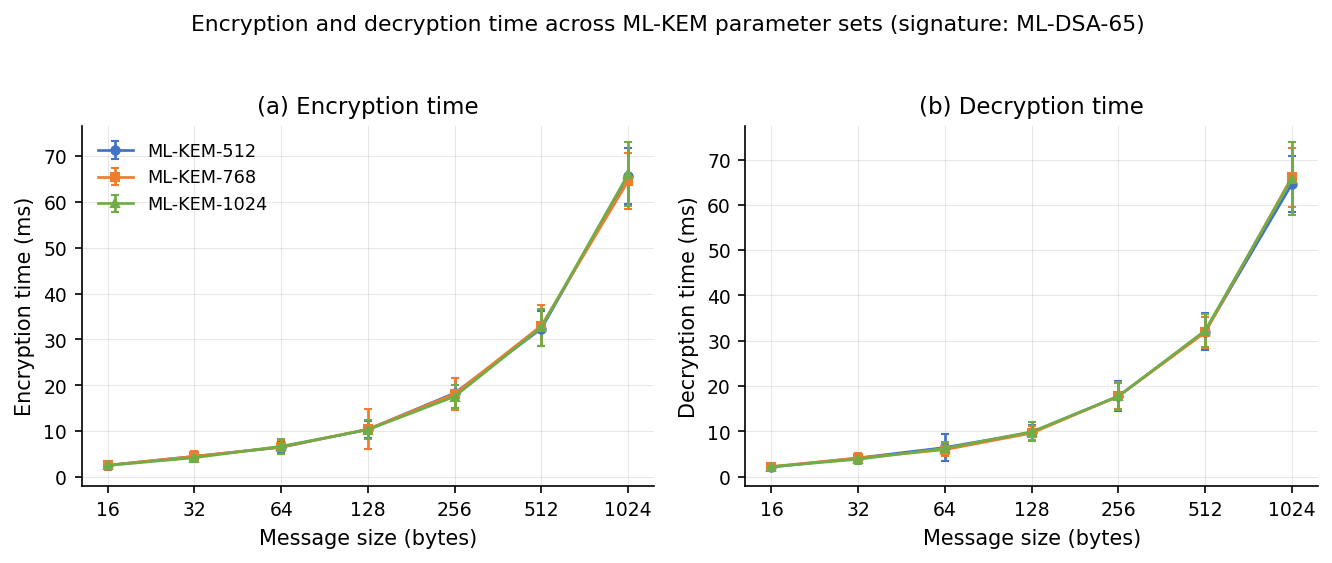

In [34]:
import json
import matplotlib.pyplot as plt

with open("results.json") as f:
    R = json.load(f)

MSG  = R["msg_sizes"]
SA   = R["sweep_a"]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for kem, d in SA.items():
    c, m = KEM_COLORS[kem], KEM_MARKERS[kem]
    axes[0].errorbar(MSG, d["enc_mean"], yerr=d["enc_sd"], label=kem,
                     color=c, marker=m, markersize=4, capsize=2, linewidth=1.3)
    axes[1].errorbar(MSG, d["dec_mean"], yerr=d["dec_sd"], label=kem,
                     color=c, marker=m, markersize=4, capsize=2, linewidth=1.3)

style_axes(axes[0], "Message size (bytes)", "Encryption time (ms)", "(a) Encryption time")
style_axes(axes[1], "Message size (bytes)", "Decryption time (ms)", "(b) Decryption time")
for ax in axes:
    ax.set_xticks(MSG); ax.set_xticklabels([str(s) for s in MSG])
axes[0].legend(loc="upper left", frameon=False)
fig.suptitle("Encryption and decryption time across ML-KEM parameter sets (signature: ML-DSA-65)",
             y=1.03, fontsize=10.5)
fig.tight_layout()
fig.savefig("kem_timing.pdf"); fig.savefig("kem_timing.png")
print("Wrote kem_timing.pdf/.png")


Wrote kem_ciphertext_size.pdf/.png


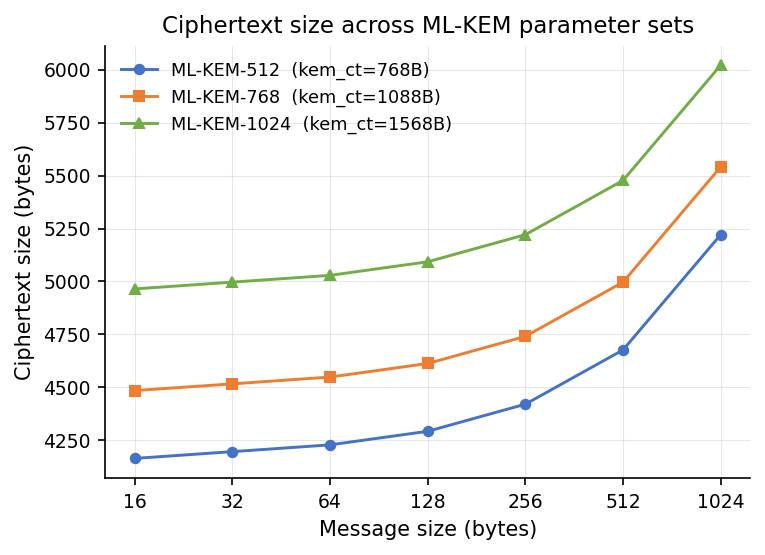

In [35]:
import json, matplotlib.pyplot as plt

with open("results.json") as f:
    R = json.load(f)

MSG = R["msg_sizes"]
SA  = R["sweep_a"]
KEM_CT = {"ML-KEM-512": 768, "ML-KEM-768": 1088, "ML-KEM-1024": 1568}

fig, ax = plt.subplots(figsize=(5.2, 3.8))
for kem, d in SA.items():
    ax.plot(MSG, d["ct"], label=f"{kem}  (kem_ct={KEM_CT[kem]}B)",
            color=KEM_COLORS[kem], marker=KEM_MARKERS[kem], markersize=4.5, linewidth=1.4)
style_axes(ax, "Message size (bytes)", "Ciphertext size (bytes)",
           "Ciphertext size across ML-KEM parameter sets")
ax.set_xticks(MSG); ax.set_xticklabels([str(s) for s in MSG])
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig("kem_ciphertext_size.pdf"); fig.savefig("kem_ciphertext_size.png")
print("Wrote kem_ciphertext_size.pdf/.png")


Wrote signature_components.pdf/.png


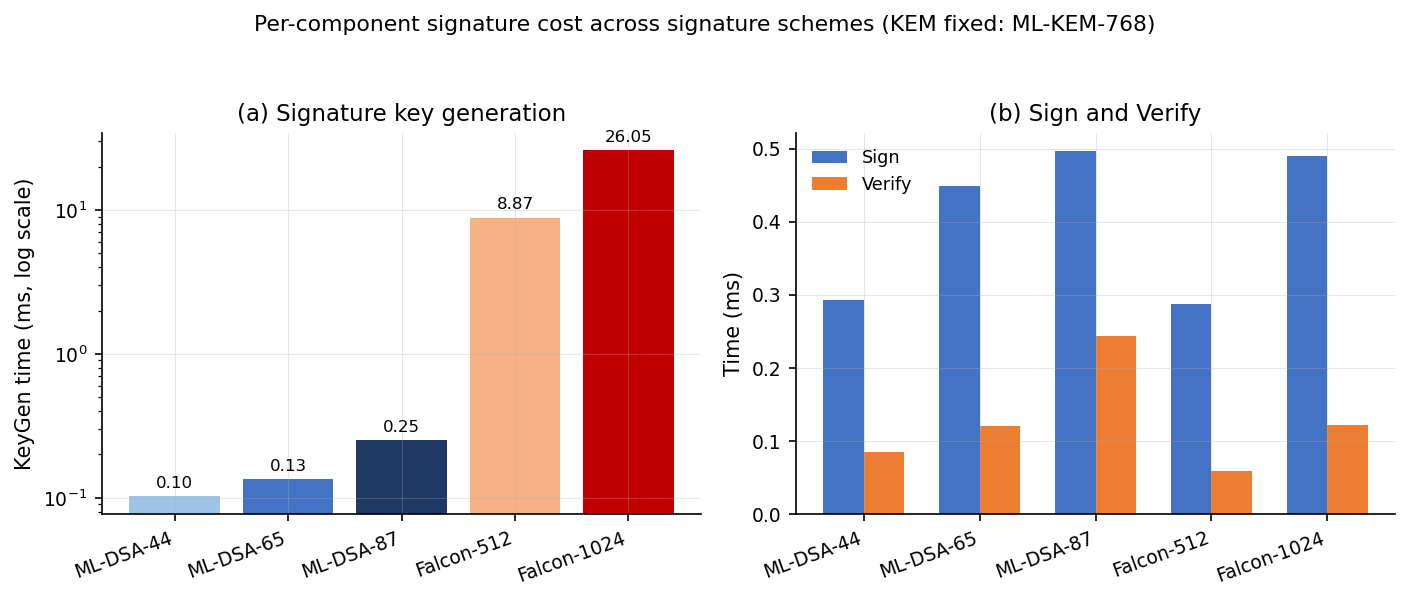

In [36]:
import json, numpy as np, matplotlib.pyplot as plt

with open("results.json") as f:
    R = json.load(f)

SB = R["sweep_b"]
schemes = list(SB.keys())
keygen  = [SB[s]["keygen_sig"] for s in schemes]
sign    = [SB[s]["sign"]       for s in schemes]
verify  = [SB[s]["verify"]     for s in schemes]
colors  = [SIG_COLORS[s]       for s in schemes]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
x = np.arange(len(schemes))

axes[0].bar(x, keygen, color=colors)
axes[0].set_yscale("log")
axes[0].set_ylabel("KeyGen time (ms, log scale)")
axes[0].set_title("(a) Signature key generation")
for i, v in enumerate(keygen):
    axes[0].text(i, v * 1.15, f"{v:.2f}", ha="center", fontsize=8)

w = 0.35
axes[1].bar(x - w/2, sign,   w, label="Sign",   color="#4472C4")
axes[1].bar(x + w/2, verify, w, label="Verify", color="#ED7D31")
axes[1].set_ylabel("Time (ms)")
axes[1].set_title("(b) Sign and Verify")
axes[1].legend(frameon=False)

for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(schemes, rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

fig.suptitle("Per-component signature cost across signature schemes (KEM fixed: ML-KEM-768)",
             y=1.04, fontsize=10.5)
fig.tight_layout()
fig.savefig("signature_components.pdf"); fig.savefig("signature_components.png")
print("Wrote signature_components.pdf/.png")


Wrote signature_ciphertext_size.pdf/.png


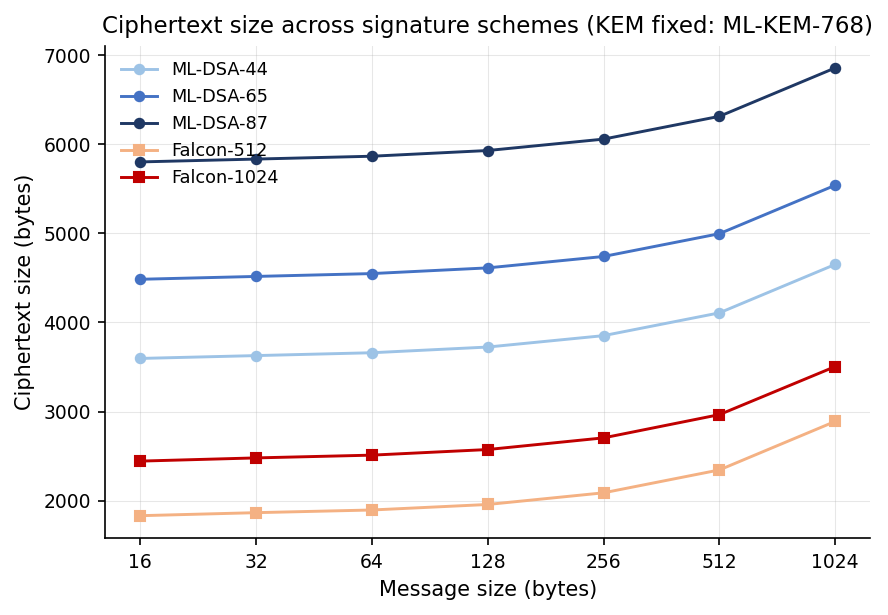

In [37]:
import json, matplotlib.pyplot as plt

with open("results.json") as f:
    R = json.load(f)

MSG = R["msg_sizes"]
SB  = R["sweep_b"]

fig, ax = plt.subplots(figsize=(6, 4.2))
for scheme, d in SB.items():
    ax.plot(MSG, d["ct"], label=scheme, color=SIG_COLORS[scheme],
            marker=SIG_MARKERS[scheme], markersize=4.5, linewidth=1.4)
style_axes(ax, "Message size (bytes)", "Ciphertext size (bytes)",
           "Ciphertext size across signature schemes (KEM fixed: ML-KEM-768)")
ax.set_xticks(MSG); ax.set_xticklabels([str(s) for s in MSG])
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig("signature_ciphertext_size.pdf"); fig.savefig("signature_ciphertext_size.png")
print("Wrote signature_ciphertext_size.pdf/.png")


Wrote head_to_head.pdf/.png


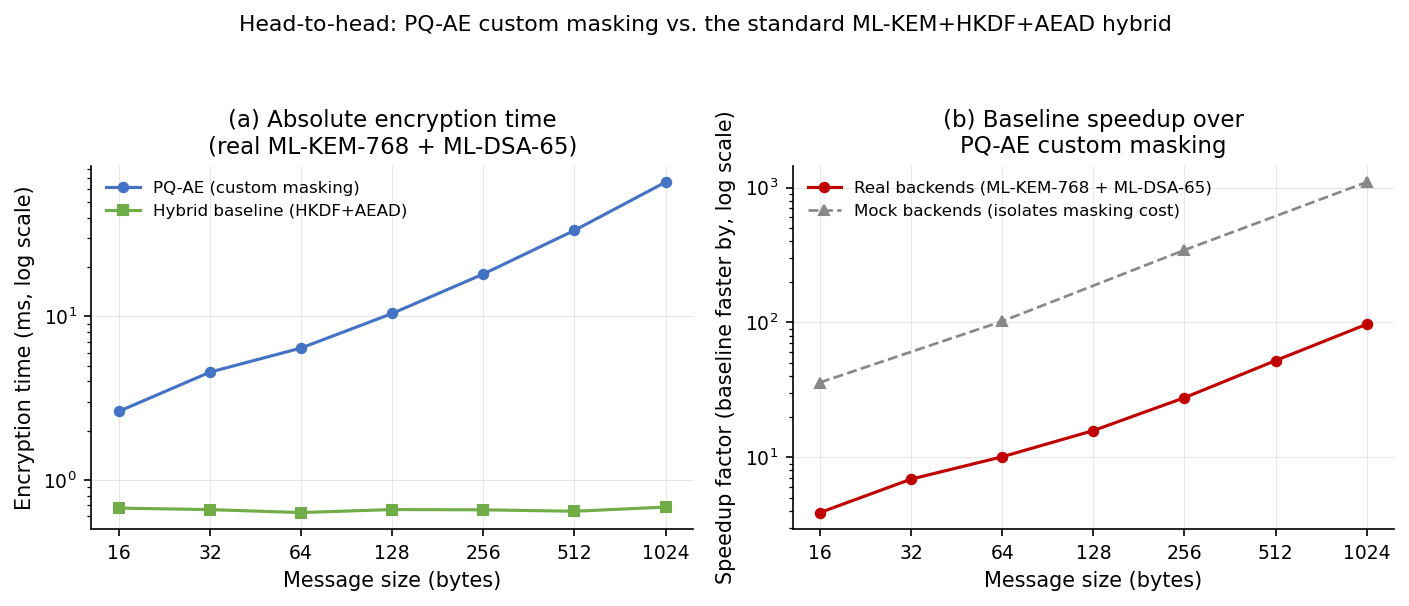

In [38]:
import json, matplotlib.pyplot as plt

with open("results.json") as f:
    R = json.load(f)

r = R["head_to_head_real"]
m = R["head_to_head_mock"]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

axes[0].plot(r["sizes"], r["enc_pqae"],     label="PQ-AE (custom masking)",
             color=PQAE_COLOR, marker="o", markersize=4.5, linewidth=1.5)
axes[0].plot(r["sizes"], r["enc_baseline"], label="Hybrid baseline (HKDF+AEAD)",
             color=BASELINE_COLOR, marker="s", markersize=4.5, linewidth=1.5)
style_axes(axes[0], "Message size (bytes)", "Encryption time (ms, log scale)",
           "(a) Absolute encryption time\n(real ML-KEM-768 + ML-DSA-65)", yscale="log")
axes[0].set_xticks(r["sizes"]); axes[0].set_xticklabels([str(s) for s in r["sizes"]])
axes[0].legend(loc="upper left", frameon=False, fontsize=8)

axes[1].plot(r["sizes"], r["speedup"], label="Real backends (ML-KEM-768 + ML-DSA-65)",
             color="#C00000", marker="o", markersize=4.5, linewidth=1.5)
axes[1].plot(m["sizes"], m["speedup"], label="Mock backends (isolates masking cost)",
             color="#888888", marker="^", markersize=4.5, linewidth=1.3, linestyle="--")
style_axes(axes[1], "Message size (bytes)",
           "Speedup factor (baseline faster by, log scale)",
           "(b) Baseline speedup over\nPQ-AE custom masking", yscale="log")
axes[1].set_xticks(r["sizes"]); axes[1].set_xticklabels([str(s) for s in r["sizes"]])
axes[1].legend(loc="upper left", frameon=False, fontsize=8)

fig.suptitle("Head-to-head: PQ-AE custom masking vs. the standard ML-KEM+HKDF+AEAD hybrid",
             y=1.05, fontsize=10.5)
fig.tight_layout()
fig.savefig("head_to_head.pdf"); fig.savefig("head_to_head.png")
print("Wrote head_to_head.pdf/.png")


Wrote head_to_head_ciphertext.pdf/.png


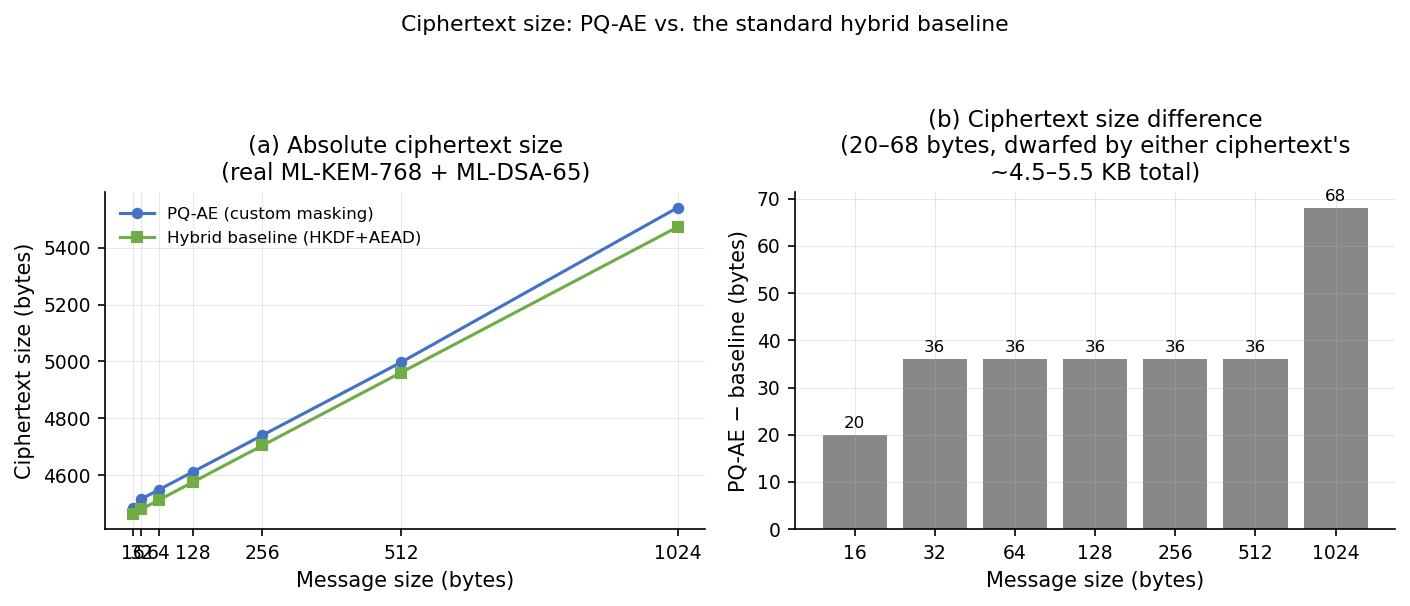

In [39]:
import json, matplotlib.pyplot as plt

with open("results.json") as f:
    R = json.load(f)

r     = R["head_to_head_real"]
delta = [a - b for a, b in zip(r["ct_pqae"], r["ct_baseline"])]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

axes[0].plot(r["sizes"], r["ct_pqae"],     label="PQ-AE (custom masking)",
             color=PQAE_COLOR, marker="o", markersize=4.5, linewidth=1.5)
axes[0].plot(r["sizes"], r["ct_baseline"], label="Hybrid baseline (HKDF+AEAD)",
             color=BASELINE_COLOR, marker="s", markersize=4.5, linewidth=1.5)
style_axes(axes[0], "Message size (bytes)", "Ciphertext size (bytes)",
           "(a) Absolute ciphertext size\n(real ML-KEM-768 + ML-DSA-65)", xscale="linear")
axes[0].set_xticks(r["sizes"]); axes[0].set_xticklabels([str(s) for s in r["sizes"]])
axes[0].legend(loc="upper left", frameon=False, fontsize=8)

axes[1].bar([str(s) for s in r["sizes"]], delta, color="#888888")
axes[1].set_xlabel("Message size (bytes)")
axes[1].set_ylabel("PQ-AE − baseline (bytes)")
axes[1].set_title("(b) Ciphertext size difference\n(20–68 bytes, dwarfed by either ciphertext's\n~4.5–5.5 KB total)")
axes[1].grid(axis="y", alpha=0.3, linewidth=0.5)
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
for i, v in enumerate(delta):
    axes[1].text(i, v + 1.5, str(v), ha="center", fontsize=8)

fig.suptitle("Ciphertext size: PQ-AE vs. the standard hybrid baseline", y=1.05, fontsize=10.5)
fig.tight_layout()
fig.savefig("head_to_head_ciphertext.pdf"); fig.savefig("head_to_head_ciphertext.png")
print("Wrote head_to_head_ciphertext.pdf/.png")
